# Pandas Practice Workbook — Netflix Dataset (125 Questions)
**Prepared by Ananda Rimal** · Dataset: `netflix_titles.csv`

**Columns:** `show_id, type, title, director, cast, country, date_added, release_year, rating, duration, listed_in, description`

**Instructions**
- Write your answer in the code cell **below each question**
- Every answer must be pandas code — no manual counting
- Sections G (GroupBy) and H (Cleaning) may need columns you create along the way — read carefully

| Section | Topic | Questions |
|---------|-------|-----------|
| A | First Analysis of Data | 15 |
| B | Selection with `[]`, `.loc`, `.iloc` | 25 |
| C | Conditions (with `.loc`) | 20 |
| D | Sorting | 10 |
| E | Updating Data | 15 |
| F | GroupBy | 20 |
| G | Cleaning | 20 |
| **Total** | | **125** |

## Section A — First Analysis of Data (Q1–Q15)

#### Q1. Load the dataset into a DataFrame called `df` and display the first 5 rows.

In [1]:
import pandas as pd

# The dataset now lives in the data/ folder, one level above this notebook
df = pd.read_csv("../data/netflix_titles.csv")
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


#### Q2. Display the **last 7 rows** of the DataFrame.

In [2]:
# tail(n) shows the LAST n rows
df.tail(7)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
8800,s8801,TV Show,Zindagi Gulzar Hai,NaN,"Sanam Saeed, Fawad Khan, Ayesha Omer, Mehreen ...",Pakistan,"December 15, 2016",2012,TV-PG,1 Season,"International TV Shows, Romantic TV Shows, TV ...","Strong-willed, middle-class Kashaf and carefre..."
8801,s8802,Movie,Zinzana,Majid Al Ansari,"Ali Suliman, Saleh Bakri, Yasa, Ali Al-Jabri, ...","United Arab Emirates, Jordan","March 9, 2016",2015,TV-MA,96 min,"Dramas, International Movies, Thrillers",Recovering alcoholic Talal wakes up inside a s...
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,"November 20, 2019",2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a..."
8803,s8804,TV Show,Zombie Dumb,NaN,NaN,NaN,"July 1, 2019",2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g..."
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,"November 1, 2019",2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,"January 11, 2020",2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero..."
8806,s8807,Movie,Zubaan,Mozez Singh,"Vicky Kaushal, Sarah-Jane Dias, Raaghav Chanan...",India,"March 2, 2019",2015,TV-14,111 min,"Dramas, International Movies, Music & Musicals",A scrappy but poor boy worms his way into a ty...


#### Q3. How many rows and columns does the dataset have?

In [3]:
# .shape returns a tuple: (rows, columns)
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
df.shape

Rows: 8807
Columns: 12


(8807, 12)

#### Q4. Display the names of all columns.

In [4]:
# .columns holds the column labels
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

#### Q5. Use `info()` — which columns have missing values, and what is the data type of each column?

In [5]:
# info() gives dtype + non-null count for every column in one view.
# Any column whose "Non-Null Count" is less than the total row count has missing values.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


#### Q6. Use `describe()` on the numeric columns. What is the minimum and maximum `release_year`?

In [6]:
# describe() only looks at numeric columns.
# Here release_year is the only numeric column, so min/max come straight from it.
df.describe()

,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


#### Q7. Use `describe(include="object")` on the text columns. Which value appears most often in the `type` column?

In [7]:
# include="object" switches describe() to the text columns.
# "top" = most frequent value, "freq" = how many times it appears.
# For `type`, top is "Movie".
df.describe(include="object")

,show_id,type,title,director,cast,country,date_added,rating,duration,listed_in,description
count,8807,8807,8807,6173,7982,7976,8797,8803,8804,8807,8807
unique,8807,2,8807,4528,7692,748,1767,17,220,514,8775
top,s1,Movie,Dick Johnson Is Dead,Rajiv Chilaka,David Attenborough,United States,"January 1, 2020",TV-MA,1 Season,"Dramas, International Movies","Paranormal activity at a lush, abandoned prope..."
freq,1,6131,1,19,19,2818,109,3207,1793,362,4


#### Q8. Count the missing values in **every** column with one command.

In [8]:
# isna() -> True/False table, .sum() adds the Trues per column
df.isna().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

#### Q9. Which single column has the **most** missing values?

In [9]:
# idxmax() returns the LABEL (here the column name) of the largest value
missing = df.isna().sum()
print("Column with most missing values:", missing.idxmax(), "->", missing.max())
missing.sort_values(ascending=False)

Column with most missing values: director -> 2634


director        2634
country          831
cast             825
date_added        10
rating             4
duration           3
show_id            0
type               0
title              0
release_year       0
listed_in          0
description        0
dtype: int64

#### Q10. How many **unique** values are in the `rating` column? Display them.

In [10]:
# nunique() counts distinct values, unique() lists them
print("Unique ratings:", df["rating"].nunique())
df["rating"].unique()

Unique ratings: 17


array(['PG-13', 'TV-MA', 'PG', 'TV-14', 'TV-PG', 'TV-Y', 'TV-Y7', 'R',
       'TV-G', 'G', 'NC-17', '74 min', '84 min', '66 min', 'NR', nan,
       'TV-Y7-FV', 'UR'], dtype=object)

#### Q11. Show 5 **random** rows using `sample()`.

In [11]:
# random_state fixes the randomness so the notebook gives the same rows every run
df.sample(5, random_state=42)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
4970,s4971,Movie,"Game Over, Man!",Kyle Newacheck,"Adam DeVine, Anders Holm, Blake Anderson, Utka...",United States,"March 23, 2018",2018,TV-MA,102 min,"Action & Adventure, Comedies",Three buddies with big dreams go from underach...
3362,s3363,Movie,Arsenio Hall: Smart & Classy,Brian Volk-Weiss,Arsenio Hall,United States,"October 29, 2019",2019,TV-MA,63 min,Stand-Up Comedy,"In his first stand-up special, Arsenio Hall di..."
5494,s5495,TV Show,Kazoops!,NaN,"Reece Pockney, Scott Langley, Alex Babic, Gemm...",Australia,"May 5, 2017",2017,TV-Y,3 Seasons,Kids' TV,Music meets imagination in this inventive anim...
1688,s1689,TV Show,We Are the Champions,NaN,NaN,United States,"November 17, 2020",2020,TV-MA,1 Season,"Docuseries, Reality TV","Explore an array of unique competitions, from ..."
1349,s1350,TV Show,"Pablo Escobar, el patrón del mal",NaN,"Andrés Parra, Angie Cepeda, Cecilia Navia, Vic...",Colombia,"February 3, 2021",2012,TV-MA,1 Season,"Crime TV Shows, International TV Shows, Spanis...",From his days as a petty thief to becoming hea...


#### Q12. What is the memory usage of the DataFrame? (hint: `info()` or `memory_usage()`)

In [12]:
# memory_usage(deep=True) also measures the text inside object columns
print("Total memory:", round(df.memory_usage(deep=True).sum() / 1024**2, 2), "MB")
df.memory_usage(deep=True)

Total memory: 8.52 MB


Index               132
show_id          544927
type             551386
title            665391
director         540409
cast            1496835
country          581565
date_added       631404
release_year      70456
rating           540938
duration         563918
listed_in        796204
description     1954359
dtype: int64

#### Q13. Display the data type of only the `release_year` column.

In [13]:
# .dtype (singular) works on a Series, .dtypes (plural) on a DataFrame
df["release_year"].dtype

dtype('int64')

#### Q14. Count how many titles are of each `type` using `value_counts()`.

In [14]:
# value_counts() = how many rows per unique value
df["type"].value_counts()

type
Movie      6131
TV Show    2676
Name: count, dtype: int64

#### Q15. Check: does the dataset contain any **fully duplicated** rows?

In [15]:
# duplicated() marks a row True if the WHOLE row was seen before
print("Fully duplicated rows:", df.duplicated().sum())

Fully duplicated rows: 0


## Section B — Selection with `[]`, `.loc`, `.iloc` (Q16–Q40)
*(Q16–Q30: default 0,1,2,... index · Q31–Q40: after `set_index("show_id")`)*

#### Q16. Select the `title` column as a **Series**.

In [16]:
# Single brackets -> Series (1-D)
s = df["title"]
print(type(s))
s.head()

<class 'pandas.core.series.Series'>


0     Dick Johnson Is Dead
1            Blood & Water
2                Ganglands
3    Jailbirds New Orleans
4             Kota Factory
Name: title, dtype: object

#### Q17. Select the `title` column as a **DataFrame** (hint: double brackets).

In [17]:
# Double brackets -> DataFrame (2-D), even for one column
t = df[["title"]]
print(type(t))
t.head()

<class 'pandas.core.frame.DataFrame'>


,title
0,Dick Johnson Is Dead
1,Blood & Water
2,Ganglands
3,Jailbirds New Orleans
4,Kota Factory


#### Q18. Select the columns `title`, `type`, and `country` together.

In [18]:
# Pass a LIST of column names to select several columns
df[["title", "type", "country"]].head()

,title,type,country
0,Dick Johnson Is Dead,Movie,United States
1,Blood & Water,TV Show,South Africa
2,Ganglands,TV Show,NaN
3,Jailbirds New Orleans,TV Show,NaN
4,Kota Factory,TV Show,India


#### Q19. Select the first 10 rows using `.iloc`.

In [19]:
# .iloc works on POSITIONS, and the end position is excluded
df.iloc[0:10]

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...
5,s6,TV Show,Midnight Mass,Mike Flanagan,"Kate Siegel, Zach Gilford, Hamish Linklater, H...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries",The arrival of a charismatic young priest brin...
6,s7,Movie,My Little Pony: A New Generation,"Robert Cullen, José Luis Ucha","Vanessa Hudgens, Kimiko Glenn, James Marsden, ...",NaN,"September 24, 2021",2021,PG,91 min,Children & Family Movies,Equestria's divided. But a bright-eyed hero be...
7,s8,Movie,Sankofa,Haile Gerima,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...","United States, Ghana, Burkina Faso, United Kin...","September 24, 2021",1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies","On a photo shoot in Ghana, an American model s..."
8,s9,TV Show,The Great British Baking Show,Andy Devonshire,"Mel Giedroyc, Sue Perkins, Mary Berry, Paul Ho...",United Kingdom,"September 24, 2021",2021,TV-14,9 Seasons,"British TV Shows, Reality TV",A talented batch of amateur bakers face off in...
9,s10,Movie,The Starling,Theodore Melfi,"Melissa McCarthy, Chris O'Dowd, Kevin Kline, T...",United States,"September 24, 2021",2021,PG-13,104 min,"Comedies, Dramas",A woman adjusting to life after a loss contend...


#### Q20. Select rows with labels 10 to 20 using `.loc`. How many rows do you get and why?

In [20]:
# .loc slices by LABEL and INCLUDES the end label -> 11 rows (10,11,...,20)
rows = df.loc[10:20]
print("Rows returned:", len(rows), "-> loc label slicing includes the end label")
rows

Rows returned: 11 -> loc label slicing includes the end label


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
10,s11,TV Show,"Vendetta: Truth, Lies and The Mafia",NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, Docuseries, International TV S...","Sicily boasts a bold ""Anti-Mafia"" coalition. B..."
11,s12,TV Show,Bangkok Breaking,Kongkiat Komesiri,"Sukollawat Kanarot, Sushar Manaying, Pavarit M...",NaN,"September 23, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...","Struggling to earn a living in Bangkok, a man ..."
12,s13,Movie,Je Suis Karl,Christian Schwochow,"Luna Wedler, Jannis Niewöhner, Milan Peschel, ...","Germany, Czech Republic","September 23, 2021",2021,TV-MA,127 min,"Dramas, International Movies",After most of her family is murdered in a terr...
13,s14,Movie,Confessions of an Invisible Girl,Bruno Garotti,"Klara Castanho, Lucca Picon, Júlia Gomes, Marc...",NaN,"September 22, 2021",2021,TV-PG,91 min,"Children & Family Movies, Comedies",When the clever but socially-awkward Tetê join...
14,s15,TV Show,Crime Stories: India Detectives,NaN,NaN,NaN,"September 22, 2021",2021,TV-MA,1 Season,"British TV Shows, Crime TV Shows, Docuseries",Cameras following Bengaluru police on the job ...
15,s16,TV Show,Dear White People,NaN,"Logan Browning, Brandon P. Bell, DeRon Horton,...",United States,"September 22, 2021",2021,TV-MA,4 Seasons,"TV Comedies, TV Dramas",Students of color navigate the daily slights a...
16,s17,Movie,Europe's Most Dangerous Man: Otto Skorzeny in ...,"Pedro de Echave García, Pablo Azorín Williams",NaN,NaN,"September 22, 2021",2020,TV-MA,67 min,"Documentaries, International Movies",Declassified documents reveal the post-WWII li...
17,s18,TV Show,Falsa identidad,NaN,"Luis Ernesto Franco, Camila Sodi, Sergio Goyri...",Mexico,"September 22, 2021",2020,TV-MA,2 Seasons,"Crime TV Shows, Spanish-Language TV Shows, TV ...",Strangers Diego and Isabel flee their home in ...
18,s19,Movie,Intrusion,Adam Salky,"Freida Pinto, Logan Marshall-Green, Robert Joh...",NaN,"September 22, 2021",2021,TV-14,94 min,Thrillers,After a deadly home invasion at a couple’s new...
19,s20,TV Show,Jaguar,NaN,"Blanca Suárez, Iván Marcos, Óscar Casas, Adriá...",NaN,"September 22, 2021",2021,TV-MA,1 Season,"International TV Shows, Spanish-Language TV Sh...","In the 1960s, a Holocaust survivor joins a gro..."


#### Q21. Using `.iloc`, select rows at positions 5 to 14 (10 rows). Compare with Q20 — why is the row count logic different?

In [21]:
# .iloc slices by POSITION and EXCLUDES the end -> 5,6,...,14 = 10 rows
rows = df.iloc[5:15]
print("Rows returned:", len(rows), "-> iloc position slicing excludes the end")
rows

Rows returned: 10 -> iloc position slicing excludes the end


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
5,s6,TV Show,Midnight Mass,Mike Flanagan,"Kate Siegel, Zach Gilford, Hamish Linklater, H...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries",The arrival of a charismatic young priest brin...
6,s7,Movie,My Little Pony: A New Generation,"Robert Cullen, José Luis Ucha","Vanessa Hudgens, Kimiko Glenn, James Marsden, ...",NaN,"September 24, 2021",2021,PG,91 min,Children & Family Movies,Equestria's divided. But a bright-eyed hero be...
7,s8,Movie,Sankofa,Haile Gerima,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...","United States, Ghana, Burkina Faso, United Kin...","September 24, 2021",1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies","On a photo shoot in Ghana, an American model s..."
8,s9,TV Show,The Great British Baking Show,Andy Devonshire,"Mel Giedroyc, Sue Perkins, Mary Berry, Paul Ho...",United Kingdom,"September 24, 2021",2021,TV-14,9 Seasons,"British TV Shows, Reality TV",A talented batch of amateur bakers face off in...
9,s10,Movie,The Starling,Theodore Melfi,"Melissa McCarthy, Chris O'Dowd, Kevin Kline, T...",United States,"September 24, 2021",2021,PG-13,104 min,"Comedies, Dramas",A woman adjusting to life after a loss contend...
10,s11,TV Show,"Vendetta: Truth, Lies and The Mafia",NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, Docuseries, International TV S...","Sicily boasts a bold ""Anti-Mafia"" coalition. B..."
11,s12,TV Show,Bangkok Breaking,Kongkiat Komesiri,"Sukollawat Kanarot, Sushar Manaying, Pavarit M...",NaN,"September 23, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...","Struggling to earn a living in Bangkok, a man ..."
12,s13,Movie,Je Suis Karl,Christian Schwochow,"Luna Wedler, Jannis Niewöhner, Milan Peschel, ...","Germany, Czech Republic","September 23, 2021",2021,TV-MA,127 min,"Dramas, International Movies",After most of her family is murdered in a terr...
13,s14,Movie,Confessions of an Invisible Girl,Bruno Garotti,"Klara Castanho, Lucca Picon, Júlia Gomes, Marc...",NaN,"September 22, 2021",2021,TV-PG,91 min,"Children & Family Movies, Comedies",When the clever but socially-awkward Tetê join...
14,s15,TV Show,Crime Stories: India Detectives,NaN,NaN,NaN,"September 22, 2021",2021,TV-MA,1 Season,"British TV Shows, Crime TV Shows, Docuseries",Cameras following Bengaluru police on the job ...


#### Q22. Using `.loc`, select rows 0 to 9 with only the columns `title` and `release_year`.

In [22]:
# loc[row_slice, column_list]
df.loc[0:9, ["title", "release_year"]]

,title,release_year
0,Dick Johnson Is Dead,2020
1,Blood & Water,2021
2,Ganglands,2021
3,Jailbirds New Orleans,2021
4,Kota Factory,2021
5,Midnight Mass,2021
6,My Little Pony: A New Generation,2021
7,Sankofa,1993
8,The Great British Baking Show,2021
9,The Starling,2021


#### Q23. Using `.iloc`, select the first 8 rows and the first 5 columns.

In [23]:
# iloc[row_positions, column_positions]
df.iloc[0:8, 0:5]

,show_id,type,title,director,cast
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi..."
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K..."
5,s6,TV Show,Midnight Mass,Mike Flanagan,"Kate Siegel, Zach Gilford, Hamish Linklater, H..."
6,s7,Movie,My Little Pony: A New Generation,"Robert Cullen, José Luis Ucha","Vanessa Hudgens, Kimiko Glenn, James Marsden, ..."
7,s8,Movie,Sankofa,Haile Gerima,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D..."


#### Q24. Using `.iloc`, select the **last row** of the DataFrame.

In [24]:
# -1 means "last position"
df.iloc[-1]

show_id                                                     s8807
type                                                        Movie
title                                                      Zubaan
director                                              Mozez Singh
cast            Vicky Kaushal, Sarah-Jane Dias, Raaghav Chanan...
country                                                     India
date_added                                          March 2, 2019
release_year                                                 2015
rating                                                      TV-14
duration                                                  111 min
listed_in          Dramas, International Movies, Music & Musicals
description     A scrappy but poor boy worms his way into a ty...
Name: 8806, dtype: object

#### Q25. Using `.iloc`, select the last 5 rows and the last 2 columns (negative positions).

In [25]:
# last 5 rows, last 2 columns
df.iloc[-5:, -2:]

,listed_in,description
8802,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a..."
8803,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g..."
8804,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...
8805,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero..."
8806,"Dramas, International Movies, Music & Musicals",A scrappy but poor boy worms his way into a ty...


#### Q26. Using `.loc`, get the value of `title` for the row with label 50.

In [26]:
# loc[row_label, column_label] returns the single value
df.loc[50, "title"]

'Dharmakshetra'

#### Q27. Using `.iloc`, get the value in row position 100, column position 2. Which column is that?

In [27]:
# Column position 2 is "title" (0=show_id, 1=type, 2=title)
print("Column at position 2:", df.columns[2])
df.iloc[100, 2]

Column at position 2: title


'Tobot Galaxy Detectives'

#### Q28. Using `.iloc`, select every 100th row (hint: slicing with a step `::100`).

In [28]:
# start:stop:step -> take every 100th row
df.iloc[::100]

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
100,s101,TV Show,Tobot Galaxy Detectives,NaN,"Austin Abell, Travis Turner, Cole Howard, Anna...",NaN,"September 7, 2021",2019,TV-Y7,2 Seasons,Kids' TV,An intergalactic device transforms toy cars in...
200,s201,Movie,Krishna Cottage,Santram Varma,"Sohail Khan, Isha Koppikar, Natassha, Rati Agn...",India,"August 27, 2021",2004,TV-14,124 min,"Action & Adventure, Horror Movies, Internation...",True love is put to the test when another woma...
300,s301,Movie,Vivo,"Kirk DeMicco, Brandon Jeffords","Lin-Manuel Miranda, Ynairaly Simo, Zoe Saldana...","Canada, United States","August 6, 2021",2021,PG,100 min,"Children & Family Movies, Music & Musicals",A music-loving kinkajou embarks on the journey...
400,s401,TV Show,Revelations: The Masters of the Universe: Reve...,NaN,"Kevin Smith, Tiffany Smith, Robert David, Sara...",NaN,"July 23, 2021",2021,TV-PG,1 Season,"Anime Series, Stand-Up Comedy & Talk Shows",Take a behind-the-scenes look at “Masters of t...
...,...,...,...,...,...,...,...,...,...,...,...,...
8400,s8401,Movie,The Long Goodbye: The Kara Tippetts Story,Jay Lyons,NaN,United States,"June 23, 2019",2019,TV-PG,87 min,"Documentaries, Faith & Spirituality","Faced with terminal breast cancer, a courageou..."
8500,s8501,Movie,The Search for Life in Space,Stephen Amezdroz,NaN,United States,"April 1, 2018",2016,TV-G,32 min,Documentaries,To determine whether we're alone in the univer...
8600,s8601,TV Show,Tobot,NaN,"Octavian Kaul, Valin Shinyei, Chelsea Miller, ...",Canada,"September 11, 2019",2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows",They’re robots that can transform into cars – ...
8700,s8701,TV Show,Wartime Portraits,NaN,NaN,Poland,"September 15, 2016",2014,TV-MA,1 Season,"Docuseries, International TV Shows","Part live-action and part animation, this visu..."


#### Q29. Using `.loc`, select rows 0 to 4 and **all** columns from `title` to `country` (label slicing on columns!).

In [29]:
# Column slicing by LABEL: "title":"country" includes BOTH ends
df.loc[0:4, "title":"country"]

,title,director,cast,country
0,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States
1,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa
2,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN
3,Jailbirds New Orleans,NaN,NaN,NaN
4,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India


#### Q30. Select three specific rows by label — 3, 33, and 333 — in one `.loc` call.

In [30]:
# A list of labels picks exactly those rows (order is kept)
df.loc[[3, 33, 333]]

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
33,s34,TV Show,Squid Game,NaN,"Lee Jung-jae, Park Hae-soo, Wi Ha-jun, Oh Youn...",NaN,"September 17, 2021",2021,TV-MA,1 Season,"International TV Shows, TV Dramas, TV Thrillers",Hundreds of cash-strapped players accept a str...
333,s334,Movie,Ferris Bueller's Day Off,John Hughes,"Matthew Broderick, Alan Ruck, Mia Sara, Jeffre...",United States,"August 1, 2021",1986,PG-13,103 min,"Classic Movies, Comedies, Cult Movies","After faking an illness to skip school, popula..."


#### Q31. Set `show_id` as the index of `df` (keep it for the rest of Section B). Display the head.

In [31]:
# Reassigning df keeps the new index for the rest of Section B
df = df.set_index("show_id")
df.head()

,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
show_id,,,,,,,,,,,
s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


#### Q32. Using `.loc`, select the row with label `"s1"`.

In [32]:
# The index is now text, so the label is the string "s1"
df.loc["s1"]

type                                                        Movie
title                                        Dick Johnson Is Dead
director                                          Kirsten Johnson
cast                                                          NaN
country                                             United States
date_added                                     September 25, 2021
release_year                                                 2020
rating                                                      PG-13
duration                                                   90 min
listed_in                                           Documentaries
description     As her father nears the end of his life, filmm...
Name: s1, dtype: object

#### Q33. Using `.loc`, select rows `"s10"` to `"s15"`. Does label slicing still include the end?

In [33]:
# Yes - label slicing still includes the end label, so "s15" is returned too
rows = df.loc["s10":"s15"]
print("Rows returned:", len(rows), "-> 's15' is included")
rows

Rows returned: 6 -> 's15' is included


,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
show_id,,,,,,,,,,,
s10,Movie,The Starling,Theodore Melfi,"Melissa McCarthy, Chris O'Dowd, Kevin Kline, T...",United States,"September 24, 2021",2021,PG-13,104 min,"Comedies, Dramas",A woman adjusting to life after a loss contend...
s11,TV Show,"Vendetta: Truth, Lies and The Mafia",NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, Docuseries, International TV S...","Sicily boasts a bold ""Anti-Mafia"" coalition. B..."
s12,TV Show,Bangkok Breaking,Kongkiat Komesiri,"Sukollawat Kanarot, Sushar Manaying, Pavarit M...",NaN,"September 23, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...","Struggling to earn a living in Bangkok, a man ..."
s13,Movie,Je Suis Karl,Christian Schwochow,"Luna Wedler, Jannis Niewöhner, Milan Peschel, ...","Germany, Czech Republic","September 23, 2021",2021,TV-MA,127 min,"Dramas, International Movies",After most of her family is murdered in a terr...
s14,Movie,Confessions of an Invisible Girl,Bruno Garotti,"Klara Castanho, Lucca Picon, Júlia Gomes, Marc...",NaN,"September 22, 2021",2021,TV-PG,91 min,"Children & Family Movies, Comedies",When the clever but socially-awkward Tetê join...
s15,TV Show,Crime Stories: India Detectives,NaN,NaN,NaN,"September 22, 2021",2021,TV-MA,1 Season,"British TV Shows, Crime TV Shows, Docuseries",Cameras following Bengaluru police on the job ...


#### Q34. Using `.iloc`, select the row at position 0. Is it the same row as label `"s1"`?

In [34]:
# Position 0 is the first row, which is still the row labelled "s1"
row = df.iloc[0]
print("Label of this row:", row.name)
row

Label of this row: s1


type                                                        Movie
title                                        Dick Johnson Is Dead
director                                          Kirsten Johnson
cast                                                          NaN
country                                             United States
date_added                                     September 25, 2021
release_year                                                 2020
rating                                                      PG-13
duration                                                   90 min
listed_in                                           Documentaries
description     As her father nears the end of his life, filmm...
Name: s1, dtype: object

#### Q35. Using `.loc`, get the `title` and `type` of the show with id `"s500"`.

In [35]:
df.loc["s500", ["title", "type"]]

title       Dogs
type     TV Show
Name: s500, dtype: object

#### Q36. Using `.iloc`, select the row at position 499. Is its label `"s500"`? Explain why or why not in a comment.

In [36]:
# Its label IS "s500" here, but only because this file happens to be stored
# in order s1, s2, s3, ... with no gaps and no sorting applied.
# Position and label are NOT the same thing - after a sort or a filter,
# position 499 could easily be some other show_id.
row = df.iloc[499]
print("Label at position 499:", row.name)
row

Label at position 499: s500


type                                                      TV Show
title                                                        Dogs
director                                                      NaN
cast                                                          NaN
country                                             United States
date_added                                           July 7, 2021
release_year                                                 2021
rating                                                      TV-PG
duration                                                2 Seasons
listed_in                                              Docuseries
description     These six intimate stories explore the abiding...
Name: s500, dtype: object

#### Q37. Using `.loc`, select shows `"s1"`, `"s100"`, and `"s1000"` with columns `title` and `release_year`.

In [37]:
# List of labels for rows, list of labels for columns
df.loc[["s1", "s100", "s1000"], ["title", "release_year"]]

,title,release_year
show_id,,
s1,Dick Johnson Is Dead,2020
s100,On the Verge,2021
s1000,Stowaway,2021


#### Q38. What happens if you run `df.loc[0]` now? Try it, read the error, and explain in a comment.

In [38]:
# df.loc[0] fails now because .loc needs a LABEL, and after set_index("show_id")
# the labels are "s1", "s2", ... - there is no label 0 any more.
# (df.iloc[0] would still work, because 0 is a valid POSITION.)
try:
    df.loc[0]
except KeyError as e:
    print("KeyError ->", e)

KeyError -> 0


#### Q39. Using `.iloc`, select rows at positions [0, 99, 999] in one call.

In [39]:
# A list of POSITIONS
df.iloc[[0, 99, 999]]

,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
show_id,,,,,,,,,,,
s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
s100,TV Show,On the Verge,NaN,"Julie Delpy, Elisabeth Shue, Sarah Jones, Alex...","France, United States","September 7, 2021",2021,TV-MA,1 Season,"TV Comedies, TV Dramas","Four women — a chef, a single mom, an heiress ..."
s1000,Movie,Stowaway,Joe Penna,"Anna Kendrick, Toni Collette, Daniel Dae Kim, ...","Germany, United States","April 22, 2021",2021,TV-MA,116 min,"Dramas, International Movies, Thrillers",A three-person crew on a mission to Mars faces...


#### Q40. Reset the index back to 0,1,2,... using `reset_index()`. Display the head.

In [40]:
# reset_index() turns show_id back into a normal column and restores 0,1,2,...
df = df.reset_index()
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


## Section C — Conditions with `.loc` (Q41–Q60)
*Write every filter with `df.loc[condition]` or `df.loc[condition, columns]` style where possible.*

#### Q41. Select all rows where `type` is `"Movie"`.

In [41]:
# df.loc[condition] keeps only the rows where the condition is True
df.loc[df["type"] == "Movie"]

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
6,s7,Movie,My Little Pony: A New Generation,"Robert Cullen, José Luis Ucha","Vanessa Hudgens, Kimiko Glenn, James Marsden, ...",NaN,"September 24, 2021",2021,PG,91 min,Children & Family Movies,Equestria's divided. But a bright-eyed hero be...
7,s8,Movie,Sankofa,Haile Gerima,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...","United States, Ghana, Burkina Faso, United Kin...","September 24, 2021",1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies","On a photo shoot in Ghana, an American model s..."
9,s10,Movie,The Starling,Theodore Melfi,"Melissa McCarthy, Chris O'Dowd, Kevin Kline, T...",United States,"September 24, 2021",2021,PG-13,104 min,"Comedies, Dramas",A woman adjusting to life after a loss contend...
12,s13,Movie,Je Suis Karl,Christian Schwochow,"Luna Wedler, Jannis Niewöhner, Milan Peschel, ...","Germany, Czech Republic","September 23, 2021",2021,TV-MA,127 min,"Dramas, International Movies",After most of her family is murdered in a terr...
...,...,...,...,...,...,...,...,...,...,...,...,...
8801,s8802,Movie,Zinzana,Majid Al Ansari,"Ali Suliman, Saleh Bakri, Yasa, Ali Al-Jabri, ...","United Arab Emirates, Jordan","March 9, 2016",2015,TV-MA,96 min,"Dramas, International Movies, Thrillers",Recovering alcoholic Talal wakes up inside a s...
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,"November 20, 2019",2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a..."
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,"November 1, 2019",2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,"January 11, 2020",2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero..."


#### Q42. Select all rows where `type` is `"TV Show"` — show only `title` and `country` using one `.loc` call.

In [42]:
# df.loc[condition, columns] filters rows AND picks columns in one step
df.loc[df["type"] == "TV Show", ["title", "country"]]

,title,country
1,Blood & Water,South Africa
2,Ganglands,NaN
3,Jailbirds New Orleans,NaN
4,Kota Factory,India
5,Midnight Mass,NaN
...,...,...
8795,Yu-Gi-Oh! Arc-V,"Japan, Canada"
8796,Yunus Emre,Turkey
8797,Zak Storm,"United States, France, South Korea, Indonesia"
8800,Zindagi Gulzar Hai,Pakistan


#### Q43. Select all titles released in 2021.

In [43]:
df.loc[df["release_year"] == 2021]

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...
5,s6,TV Show,Midnight Mass,Mike Flanagan,"Kate Siegel, Zach Gilford, Hamish Linklater, H...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries",The arrival of a charismatic young priest brin...
...,...,...,...,...,...,...,...,...,...,...,...,...
1468,s1469,Movie,What Happened to Mr. Cha?,Kim Dong-kyu,"Cha In-pyo, Cho Dal-hwan, Song Jae-ryong",South Korea,"January 1, 2021",2021,TV-MA,102 min,"Comedies, International Movies","With the peak of his career long behind him, a..."
1551,s1552,TV Show,Hilda,NaN,"Bella Ramsey, Ameerah Falzon-Ojo, Oliver Nelso...","United Kingdom, Canada, United States","December 14, 2020",2021,TV-Y7,2 Seasons,Kids' TV,"Fearless, free-spirited Hilda finds new friend..."
1696,s1697,TV Show,Polly Pocket,NaN,"Emily Tennant, Shannon Chan-Kent, Kazumi Evans...","Canada, United States, Ireland","November 15, 2020",2021,TV-Y,2 Seasons,Kids' TV,After uncovering a magical locket that allows ...
2920,s2921,TV Show,Love Is Blind,NaN,"Nick Lachey, Vanessa Lachey",United States,"February 13, 2020",2021,TV-MA,1 Season,"Reality TV, Romantic TV Shows",Nick and Vanessa Lachey host this social exper...


#### Q44. Select all titles released **before** 2000.

In [44]:
df.loc[df["release_year"] < 2000]

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
7,s8,Movie,Sankofa,Haile Gerima,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...","United States, Ghana, Burkina Faso, United Kin...","September 24, 2021",1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies","On a photo shoot in Ghana, an American model s..."
22,s23,Movie,Avvai Shanmughi,K.S. Ravikumar,"Kamal Hassan, Meena, Gemini Ganesan, Heera Raj...",NaN,"September 21, 2021",1996,TV-PG,161 min,"Comedies, International Movies",Newly divorced and denied visitation rights wi...
24,s25,Movie,Jeans,S. Shankar,"Prashanth, Aishwarya Rai Bachchan, Sri Lakshmi...",India,"September 21, 2021",1998,TV-14,166 min,"Comedies, International Movies, Romantic Movies",When the father of the man she loves insists t...
26,s27,Movie,Minsara Kanavu,Rajiv Menon,"Arvind Swamy, Kajol, Prabhu Deva, Nassar, S.P....",NaN,"September 21, 2021",1997,TV-PG,147 min,"Comedies, International Movies, Music & Musicals",A tangled love triangle ensues when a man fall...
41,s42,Movie,Jaws,Steven Spielberg,"Roy Scheider, Robert Shaw, Richard Dreyfuss, L...",United States,"September 16, 2021",1975,PG,124 min,"Action & Adventure, Classic Movies, Dramas",When an insatiable great white shark terrorize...
...,...,...,...,...,...,...,...,...,...,...,...,...
8745,s8746,Movie,Willy Wonka & the Chocolate Factory,Mel Stuart,"Gene Wilder, Jack Albertson, Peter Ostrum, Roy...","United States, East Germany, West Germany","January 1, 2020",1971,G,100 min,"Children & Family Movies, Classic Movies, Come...",Zany Willy Wonka causes a stir when he announc...
8748,s8749,Movie,Winter of Our Dreams,John Duigan,"Judy Davis, Bryan Brown, Cathy Downes, Baz Luh...",Australia,"November 1, 2016",1981,NR,86 min,"Classic Movies, Dramas","After the death of a long-ago lover, married p..."
8763,s8764,Movie,WWII: Report from the Aleutians,John Huston,NaN,United States,"March 31, 2017",1943,TV-PG,45 min,Documentaries,Filmmaker John Huston narrates this Oscar-nomi...
8764,s8765,Movie,Wyatt Earp,Lawrence Kasdan,"Kevin Costner, Dennis Quaid, Gene Hackman, Dav...",United States,"January 1, 2020",1994,PG-13,191 min,Action & Adventure,Legendary lawman Wyatt Earp is continually at ...


#### Q45. Select all titles released between 2015 and 2020 (inclusive) — two conditions with `&`.

In [45]:
# Each condition needs its own ( ) because & binds tighter than >= and <=
df.loc[(df["release_year"] >= 2015) & (df["release_year"] <= 2020)]

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
16,s17,Movie,Europe's Most Dangerous Man: Otto Skorzeny in ...,"Pedro de Echave García, Pablo Azorín Williams",NaN,NaN,"September 22, 2021",2020,TV-MA,67 min,"Documentaries, International Movies",Declassified documents reveal the post-WWII li...
17,s18,TV Show,Falsa identidad,NaN,"Luis Ernesto Franco, Camila Sodi, Sergio Goyri...",Mexico,"September 22, 2021",2020,TV-MA,2 Seasons,"Crime TV Shows, Spanish-Language TV Shows, TV ...",Strangers Diego and Isabel flee their home in ...
21,s22,TV Show,Resurrection: Ertugrul,NaN,"Engin Altan Düzyatan, Serdar Gökhan, Hülya Dar...",Turkey,"September 22, 2021",2018,TV-14,5 Seasons,"International TV Shows, TV Action & Adventure,...",When a good deed unwittingly endangers his cla...
32,s33,TV Show,Sex Education,NaN,"Asa Butterfield, Gillian Anderson, Ncuti Gatwa...",United Kingdom,"September 17, 2021",2020,TV-MA,3 Seasons,"British TV Shows, International TV Shows, TV C...",Insecure Otis has all the answers when it come...
...,...,...,...,...,...,...,...,...,...,...,...,...
8796,s8797,TV Show,Yunus Emre,NaN,"Gökhan Atalay, Payidar Tüfekçioglu, Baran Akbu...",Turkey,"January 17, 2017",2016,TV-PG,2 Seasons,"International TV Shows, TV Dramas","During the Mongol invasions, Yunus Emre leaves..."
8797,s8798,TV Show,Zak Storm,NaN,"Michael Johnston, Jessica Gee-George, Christin...","United States, France, South Korea, Indonesia","September 13, 2018",2016,TV-Y7,3 Seasons,Kids' TV,Teen surfer Zak Storm is mysteriously transpor...
8801,s8802,Movie,Zinzana,Majid Al Ansari,"Ali Suliman, Saleh Bakri, Yasa, Ali Al-Jabri, ...","United Arab Emirates, Jordan","March 9, 2016",2015,TV-MA,96 min,"Dramas, International Movies, Thrillers",Recovering alcoholic Talal wakes up inside a s...
8803,s8804,TV Show,Zombie Dumb,NaN,NaN,NaN,"July 1, 2019",2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g..."


#### Q46. Select all Movies released after 2019 (two conditions).

In [46]:
df.loc[(df["type"] == "Movie") & (df["release_year"] > 2019)]

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
6,s7,Movie,My Little Pony: A New Generation,"Robert Cullen, José Luis Ucha","Vanessa Hudgens, Kimiko Glenn, James Marsden, ...",NaN,"September 24, 2021",2021,PG,91 min,Children & Family Movies,Equestria's divided. But a bright-eyed hero be...
9,s10,Movie,The Starling,Theodore Melfi,"Melissa McCarthy, Chris O'Dowd, Kevin Kline, T...",United States,"September 24, 2021",2021,PG-13,104 min,"Comedies, Dramas",A woman adjusting to life after a loss contend...
12,s13,Movie,Je Suis Karl,Christian Schwochow,"Luna Wedler, Jannis Niewöhner, Milan Peschel, ...","Germany, Czech Republic","September 23, 2021",2021,TV-MA,127 min,"Dramas, International Movies",After most of her family is murdered in a terr...
13,s14,Movie,Confessions of an Invisible Girl,Bruno Garotti,"Klara Castanho, Lucca Picon, Júlia Gomes, Marc...",NaN,"September 22, 2021",2021,TV-PG,91 min,"Children & Family Movies, Comedies",When the clever but socially-awkward Tetê join...
...,...,...,...,...,...,...,...,...,...,...,...,...
3046,s3047,Movie,All the Freckles in the World,Yibrán Asuad,"Hánssel Casillas, Loreto Peralta, Andrea Sutto...",Mexico,"January 3, 2020",2020,TV-14,90 min,"Comedies, International Movies, Romantic Movies",Thirteen-year-old José Miguel is immune to 199...
3060,s3061,Movie,Ghost Stories,"Anurag Kashyap, Dibakar Banerjee, Karan Johar,...","Janhvi Kapoor, Sobhita Dhulipala, Sukant Goel,...",India,"January 1, 2020",2020,TV-MA,145 min,"Horror Movies, International Movies, Thrillers","The directors of Emmy-nominated ""Lust Stories""..."
5972,s5973,Movie,#cats_the_mewvie,Michael Margolis,NaN,Canada,"February 5, 2020",2020,TV-14,90 min,"Documentaries, International Movies",This pawesome documentary explores how our fel...
7594,s7595,Movie,Norm of the North: Family Vacation,Anthony Bell,"Andrew Toth, Lisa Durupt, Jonathan Holmes, Pau...",United States,"May 25, 2020",2020,TV-Y7,89 min,Children & Family Movies,"Stressed by his duties as king and father, Nor..."


#### Q47. Select all titles where `rating` is `"TV-MA"`.

In [47]:
df.loc[df["rating"] == "TV-MA"]

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...
5,s6,TV Show,Midnight Mass,Mike Flanagan,"Kate Siegel, Zach Gilford, Hamish Linklater, H...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries",The arrival of a charismatic young priest brin...
...,...,...,...,...,...,...,...,...,...,...,...,...
8762,s8763,Movie,Wrong Side Raju,Mikhil Musale,"Pratik Gandhi, Kimberley Louisa McBeath, Asif ...",India,"October 1, 2017",2016,TV-MA,140 min,"Dramas, International Movies",The life of a chauffeur and part-time bootlegg...
8769,s8770,Movie,Y.M.I.: Yeh Mera India,N. Chandra,"Anupam Kher, Atul Kulkarni, Aakash Pandey, Mil...",India,"March 1, 2018",2008,TV-MA,137 min,"Dramas, Independent Movies, International Movies","The lives of a middle-aged soap opera addict, ..."
8788,s8789,Movie,You Carry Me,Ivona Juka,"Lana Baric, Vojislav Brajovic, Natasa Janjic, ...","Croatia, Slovenia, Serbia, Montenegro","July 1, 2016",2015,TV-MA,157 min,"Dramas, International Movies","A soap opera producer, director and makeup art..."
8798,s8799,Movie,Zed Plus,Chandra Prakash Dwivedi,"Adil Hussain, Mona Singh, K.K. Raina, Sanjay M...",India,"December 31, 2019",2014,TV-MA,131 min,"Comedies, Dramas, International Movies",A philandering small-town mechanic's political...


#### Q48. Select all titles where `rating` is either `"PG"` or `"PG-13"` using `.isin()`.

In [48]:
# isin() is the clean way to test "is it one of these values?"
df.loc[df["rating"].isin(["PG", "PG-13"])]

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
6,s7,Movie,My Little Pony: A New Generation,"Robert Cullen, José Luis Ucha","Vanessa Hudgens, Kimiko Glenn, James Marsden, ...",NaN,"September 24, 2021",2021,PG,91 min,Children & Family Movies,Equestria's divided. But a bright-eyed hero be...
9,s10,Movie,The Starling,Theodore Melfi,"Melissa McCarthy, Chris O'Dowd, Kevin Kline, T...",United States,"September 24, 2021",2021,PG-13,104 min,"Comedies, Dramas",A woman adjusting to life after a loss contend...
27,s28,Movie,Grown Ups,Dennis Dugan,"Adam Sandler, Kevin James, Chris Rock, David S...",United States,"September 20, 2021",2010,PG-13,103 min,Comedies,Mourning the loss of their beloved junior high...
28,s29,Movie,Dark Skies,Scott Stewart,"Keri Russell, Josh Hamilton, J.K. Simmons, Dak...",United States,"September 19, 2021",2013,PG-13,97 min,"Horror Movies, Sci-Fi & Fantasy",A family’s idyllic suburban life shatters when...
...,...,...,...,...,...,...,...,...,...,...,...,...
8767,s8768,Movie,XXX: State of the Union,Lee Tamahori,"Ice Cube, Samuel L. Jackson, Willem Dafoe, Sco...",United States,"January 1, 2019",2005,PG-13,101 min,Action & Adventure,"In this action-packed follow-up to XXX, U.S. i..."
8776,s8777,Movie,Yellowbird,Christian De Vita,"Dakota Fanning, Seth Green, Christine Baranski...","France, Belgium","August 5, 2015",2014,PG,90 min,"Children & Family Movies, Comedies",An orphaned bird tags along with a flock on th...
8782,s8783,Movie,Yoga Hosers,Kevin Smith,"Harley Quinn Smith, Lily-Rose Depp, Johnny Dep...",United States,"December 2, 2016",2016,PG-13,88 min,"Comedies, Horror Movies, Independent Movies",With an all-important high school party at sta...
8793,s8794,Movie,"Yours, Mine and Ours",Raja Gosnell,"Dennis Quaid, Rene Russo, Sean Faris, Katija P...",United States,"November 20, 2019",2005,PG,88 min,"Children & Family Movies, Comedies",When a father of eight and a mother of 10 prep...


#### Q49. Select all titles where `rating` is **NOT** `"TV-MA"` (hint: `~` or `!=`).

In [49]:
# Careful: != also keeps the rows where rating is missing (NaN != "TV-MA" is True).
# Use notna() as well if you want only rows that really have a different rating.
df.loc[(df["rating"] != "TV-MA") & (df["rating"].notna())]

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
6,s7,Movie,My Little Pony: A New Generation,"Robert Cullen, José Luis Ucha","Vanessa Hudgens, Kimiko Glenn, James Marsden, ...",NaN,"September 24, 2021",2021,PG,91 min,Children & Family Movies,Equestria's divided. But a bright-eyed hero be...
8,s9,TV Show,The Great British Baking Show,Andy Devonshire,"Mel Giedroyc, Sue Perkins, Mary Berry, Paul Ho...",United Kingdom,"September 24, 2021",2021,TV-14,9 Seasons,"British TV Shows, Reality TV",A talented batch of amateur bakers face off in...
9,s10,Movie,The Starling,Theodore Melfi,"Melissa McCarthy, Chris O'Dowd, Kevin Kline, T...",United States,"September 24, 2021",2021,PG-13,104 min,"Comedies, Dramas",A woman adjusting to life after a loss contend...
13,s14,Movie,Confessions of an Invisible Girl,Bruno Garotti,"Klara Castanho, Lucca Picon, Júlia Gomes, Marc...",NaN,"September 22, 2021",2021,TV-PG,91 min,"Children & Family Movies, Comedies",When the clever but socially-awkward Tetê join...
...,...,...,...,...,...,...,...,...,...,...,...,...
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,"November 20, 2019",2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a..."
8803,s8804,TV Show,Zombie Dumb,NaN,NaN,NaN,"July 1, 2019",2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g..."
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,"November 1, 2019",2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,"January 11, 2020",2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero..."


#### Q50. Select all titles where `country` is exactly `"India"`.

In [50]:
# == matches the WHOLE cell exactly
df.loc[df["country"] == "India"]

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...
24,s25,Movie,Jeans,S. Shankar,"Prashanth, Aishwarya Rai Bachchan, Sri Lakshmi...",India,"September 21, 2021",1998,TV-14,166 min,"Comedies, International Movies, Romantic Movies",When the father of the man she loves insists t...
39,s40,TV Show,Chhota Bheem,NaN,"Vatsal Dubey, Julie Tejwani, Rupa Bhimani, Jig...",India,"September 16, 2021",2021,TV-Y7,3 Seasons,Kids' TV,"A brave, energetic little boy with superhuman ..."
50,s51,TV Show,Dharmakshetra,NaN,"Kashmira Irani, Chandan Anand, Dinesh Mehta, A...",India,"September 15, 2021",2014,TV-PG,1 Season,"International TV Shows, TV Dramas, TV Sci-Fi &...","After the ancient Great War, the god Chitragup..."
66,s67,TV Show,Raja Rasoi Aur Anya Kahaniyan,NaN,NaN,India,"September 15, 2021",2014,TV-G,1 Season,"Docuseries, International TV Shows",Explore the history and flavors of regional In...
...,...,...,...,...,...,...,...,...,...,...,...,...
8773,s8774,Movie,Yanda Kartavya Aahe,Kedar Shinde,"Ankush Choudhary, Smita Shewale, Mohan Joshi, ...",India,"January 1, 2018",2006,TV-PG,151 min,"Comedies, Dramas, International Movies",Thanks to an arranged marriage that was design...
8775,s8776,TV Show,Yeh Meri Family,NaN,"Vishesh Bansal, Mona Singh, Akarsh Khurana, Ah...",India,"August 31, 2018",2018,TV-PG,1 Season,"International TV Shows, TV Comedies","In the summer of 1998, middle child Harshu bal..."
8798,s8799,Movie,Zed Plus,Chandra Prakash Dwivedi,"Adil Hussain, Mona Singh, K.K. Raina, Sanjay M...",India,"December 31, 2019",2014,TV-MA,131 min,"Comedies, Dramas, International Movies",A philandering small-town mechanic's political...
8799,s8800,Movie,Zenda,Avadhoot Gupte,"Santosh Juvekar, Siddharth Chandekar, Sachit P...",India,"February 15, 2018",2009,TV-14,120 min,"Dramas, International Movies",A change in the leadership of a political part...


#### Q51. Select all titles where `country` **contains** `"India"` (hint: `str.contains`, use `na=False`). Why is the row count different from the previous question?

In [51]:
# str.contains() matches a cell that merely CONTAINS "India", so co-productions
# like "India, United Kingdom" are included too - that is why the count is higher
# than the exact == "India" match. na=False treats missing values as "no match".
exact = (df["country"] == "India").sum()
partial = df["country"].str.contains("India", na=False).sum()
print("exact == India :", exact)
print("contains India :", partial, "(includes co-productions)")
df.loc[df["country"].str.contains("India", na=False)]

exact == India : 972
contains India : 1046 (includes co-productions)


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...
24,s25,Movie,Jeans,S. Shankar,"Prashanth, Aishwarya Rai Bachchan, Sri Lakshmi...",India,"September 21, 2021",1998,TV-14,166 min,"Comedies, International Movies, Romantic Movies",When the father of the man she loves insists t...
29,s30,Movie,Paranoia,Robert Luketic,"Liam Hemsworth, Gary Oldman, Amber Heard, Harr...","United States, India, France","September 19, 2021",2013,PG-13,106 min,Thrillers,"Blackmailed by his company's CEO, a low-level ..."
39,s40,TV Show,Chhota Bheem,NaN,"Vatsal Dubey, Julie Tejwani, Rupa Bhimani, Jig...",India,"September 16, 2021",2021,TV-Y7,3 Seasons,Kids' TV,"A brave, energetic little boy with superhuman ..."
50,s51,TV Show,Dharmakshetra,NaN,"Kashmira Irani, Chandan Anand, Dinesh Mehta, A...",India,"September 15, 2021",2014,TV-PG,1 Season,"International TV Shows, TV Dramas, TV Sci-Fi &...","After the ancient Great War, the god Chitragup..."
...,...,...,...,...,...,...,...,...,...,...,...,...
8773,s8774,Movie,Yanda Kartavya Aahe,Kedar Shinde,"Ankush Choudhary, Smita Shewale, Mohan Joshi, ...",India,"January 1, 2018",2006,TV-PG,151 min,"Comedies, Dramas, International Movies",Thanks to an arranged marriage that was design...
8775,s8776,TV Show,Yeh Meri Family,NaN,"Vishesh Bansal, Mona Singh, Akarsh Khurana, Ah...",India,"August 31, 2018",2018,TV-PG,1 Season,"International TV Shows, TV Comedies","In the summer of 1998, middle child Harshu bal..."
8798,s8799,Movie,Zed Plus,Chandra Prakash Dwivedi,"Adil Hussain, Mona Singh, K.K. Raina, Sanjay M...",India,"December 31, 2019",2014,TV-MA,131 min,"Comedies, Dramas, International Movies",A philandering small-town mechanic's political...
8799,s8800,Movie,Zenda,Avadhoot Gupte,"Santosh Juvekar, Siddharth Chandekar, Sachit P...",India,"February 15, 2018",2009,TV-14,120 min,"Dramas, International Movies",A change in the leadership of a political part...


#### Q52. Select all Movies from the United States — show only `title` and `release_year`.

In [52]:
df.loc[(df["type"] == "Movie") & (df["country"] == "United States"), ["title", "release_year"]]

,title,release_year
0,Dick Johnson Is Dead,2020
9,The Starling,2021
27,Grown Ups,2010
28,Dark Skies,2013
41,Jaws,1975
...,...,...
8791,Young Adult,2011
8793,"Yours, Mine and Ours",2005
8802,Zodiac,2007
8804,Zombieland,2009


#### Q53. Select all titles where `director` is missing (hint: `isna()`).

In [53]:
# isna() -> True where the value is missing
df.loc[df["director"].isna()]

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...
10,s11,TV Show,"Vendetta: Truth, Lies and The Mafia",NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, Docuseries, International TV S...","Sicily boasts a bold ""Anti-Mafia"" coalition. B..."
14,s15,TV Show,Crime Stories: India Detectives,NaN,NaN,NaN,"September 22, 2021",2021,TV-MA,1 Season,"British TV Shows, Crime TV Shows, Docuseries",Cameras following Bengaluru police on the job ...
...,...,...,...,...,...,...,...,...,...,...,...,...
8795,s8796,TV Show,Yu-Gi-Oh! Arc-V,NaN,"Mike Liscio, Emily Bauer, Billy Bob Thompson, ...","Japan, Canada","May 1, 2018",2015,TV-Y7,2 Seasons,"Anime Series, Kids' TV",Now that he's discovered the Pendulum Summonin...
8796,s8797,TV Show,Yunus Emre,NaN,"Gökhan Atalay, Payidar Tüfekçioglu, Baran Akbu...",Turkey,"January 17, 2017",2016,TV-PG,2 Seasons,"International TV Shows, TV Dramas","During the Mongol invasions, Yunus Emre leaves..."
8797,s8798,TV Show,Zak Storm,NaN,"Michael Johnston, Jessica Gee-George, Christin...","United States, France, South Korea, Indonesia","September 13, 2018",2016,TV-Y7,3 Seasons,Kids' TV,Teen surfer Zak Storm is mysteriously transpor...
8800,s8801,TV Show,Zindagi Gulzar Hai,NaN,"Sanam Saeed, Fawad Khan, Ayesha Omer, Mehreen ...",Pakistan,"December 15, 2016",2012,TV-PG,1 Season,"International TV Shows, Romantic TV Shows, TV ...","Strong-willed, middle-class Kashaf and carefre..."


#### Q54. Select all titles where `director` is **not** missing.

In [54]:
# notna() is the opposite of isna()
df.loc[df["director"].notna()]

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
5,s6,TV Show,Midnight Mass,Mike Flanagan,"Kate Siegel, Zach Gilford, Hamish Linklater, H...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries",The arrival of a charismatic young priest brin...
6,s7,Movie,My Little Pony: A New Generation,"Robert Cullen, José Luis Ucha","Vanessa Hudgens, Kimiko Glenn, James Marsden, ...",NaN,"September 24, 2021",2021,PG,91 min,Children & Family Movies,Equestria's divided. But a bright-eyed hero be...
7,s8,Movie,Sankofa,Haile Gerima,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...","United States, Ghana, Burkina Faso, United Kin...","September 24, 2021",1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies","On a photo shoot in Ghana, an American model s..."
...,...,...,...,...,...,...,...,...,...,...,...,...
8801,s8802,Movie,Zinzana,Majid Al Ansari,"Ali Suliman, Saleh Bakri, Yasa, Ali Al-Jabri, ...","United Arab Emirates, Jordan","March 9, 2016",2015,TV-MA,96 min,"Dramas, International Movies, Thrillers",Recovering alcoholic Talal wakes up inside a s...
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,"November 20, 2019",2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a..."
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,"November 1, 2019",2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,"January 11, 2020",2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero..."


#### Q55. Select all TV Shows released in 2020 **or** 2021.

In [55]:
# | means OR. isin() keeps it readable when there are several values.
df.loc[(df["type"] == "TV Show") & (df["release_year"].isin([2020, 2021]))]

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...
5,s6,TV Show,Midnight Mass,Mike Flanagan,"Kate Siegel, Zach Gilford, Hamish Linklater, H...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries",The arrival of a charismatic young priest brin...
...,...,...,...,...,...,...,...,...,...,...,...,...
3369,s3370,TV Show,BoJack Horseman,NaN,"Will Arnett, Aaron Paul, Amy Sedaris, Alison B...",United States,"October 25, 2019",2020,TV-MA,6 Seasons,TV Comedies,Meet the most beloved sitcom horse of the '90s...
3433,s3434,TV Show,The Hook Up Plan,NaN,"Marc Ruchmann, Zita Hanrot, Sabrina Ouazani, J...",France,"October 11, 2019",2020,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...","When Parisian Elsa gets hung up on her ex, her..."
8125,s8126,TV Show,Super Wings,NaN,"Luca Padovan, Evan Smolin, Junah Jang, Colin C...","United States, South Korea, China","December 1, 2020",2020,TV-Y,3 Seasons,"Kids' TV, Korean TV Shows",A cheerful jet and his transforming pals striv...
8132,s8133,TV Show,Surviving R. Kelly Part II: The Reckoning,NaN,R. Kelly,United States,"April 13, 2020",2020,TV-MA,1 Season,"Crime TV Shows, Docuseries",As more women come forward with harrowing accu...


#### Q56. Select all titles whose `title` starts with the letter `"A"` (hint: `str.startswith`, `na=False`).

In [56]:
# str.startswith is case sensitive, so this is capital "A" only
df.loc[df["title"].str.startswith("A", na=False)]

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
22,s23,Movie,Avvai Shanmughi,K.S. Ravikumar,"Kamal Hassan, Meena, Gemini Ganesan, Heera Raj...",NaN,"September 21, 2021",1996,TV-PG,161 min,"Comedies, International Movies",Newly divorced and denied visitation rights wi...
30,s31,Movie,Ankahi Kahaniya,"Ashwiny Iyer Tiwari, Abhishek Chaubey, Saket C...","Abhishek Banerjee, Rinku Rajguru, Delzad Hiwal...",NaN,"September 17, 2021",2021,TV-14,111 min,"Dramas, Independent Movies, International Movies","As big city life buzzes around them, lonely so..."
37,s38,TV Show,Angry Birds,NaN,"Antti Pääkkönen, Heljä Heikkinen, Lynne Guagli...",Finland,"September 16, 2021",2018,TV-Y7,1 Season,"Kids' TV, TV Comedies","Birds Red, Chuck and their feathered friends h..."
71,s72,Movie,A StoryBots Space Adventure,David A. Vargas,"Evan Spiridellis, Erin Fitzgerald, Jeff Gill, ...",NaN,"September 14, 2021",2021,TV-Y,13 min,Children & Family Movies,Join the StoryBots and the space travelers of ...
105,s106,Movie,Angamaly Diaries,Lijo Jose Pellissery,"Antony Varghese, Reshma Rajan, Binny Rinky Ben...",India,"September 5, 2021",2017,TV-14,128 min,"Action & Adventure, Comedies, Dramas",After growing up amidst the gang wars of his h...
...,...,...,...,...,...,...,...,...,...,...,...,...
6198,s6199,TV Show,Aussie Gold Hunters,NaN,NaN,Australia,"August 1, 2017",2016,TV-MA,1 Season,"Docuseries, International TV Shows, Reality TV",Three teams of gold hunters battle all manner ...
6199,s6200,Movie,Automata,Gabe Ibáñez,"Antonio Banderas, Dylan McDermott, Melanie Gri...","Bulgaria, United States, Spain, Canada","September 8, 2017",2014,R,110 min,"International Movies, Sci-Fi & Fantasy, Thrillers","In a dystopian future, an insurance adjuster f..."
6200,s6201,Movie,Avengers: Infinity War,"Anthony Russo, Joe Russo","Robert Downey Jr., Josh Brolin, Mark Ruffalo, ...",United States,"December 25, 2018",2018,PG-13,150 min,"Action & Adventure, Sci-Fi & Fantasy",Superheroes amass to stop intergalactic sociop...
6201,s6202,Movie,Avicii: True Stories,Levan Tsikurishvili,Avicii,"Sweden, Netherlands","December 28, 2018",2017,TV-MA,97 min,"Documentaries, International Movies, Music & M...","Follow the meteoric rise of Tim Bergling, aka ..."


#### Q57. Select all titles whose `title` contains the word `"Love"`.

In [57]:
# case=False makes it match Love, love, LOVE ...
df.loc[df["title"].str.contains("Love", case=False, na=False)]

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
25,s26,TV Show,Love on the Spectrum,NaN,Brooke Satchwell,Australia,"September 21, 2021",2021,TV-14,2 Seasons,"Docuseries, International TV Shows, Reality TV",Finding love can be hard for anyone. For young...
158,s159,Movie,Love Don't Cost a Thing,Troy Byer,"Nick Cannon, Christina Milian, Kenan Thompson,...",United States,"September 1, 2021",2003,PG-13,101 min,"Comedies, Romantic Movies",A nerdy teen tries to make himself cool by ass...
159,s160,Movie,Love in a Puff,Pang Ho-cheung,"Miriam Chin Wah Yeung, Shawn Yue, Singh Hartih...",Hong Kong,"September 1, 2021",2010,TV-MA,103 min,"Comedies, Dramas, International Movies",When the Hong Kong government enacts a ban on ...
206,s207,Movie,"LSD: Love, Sex Aur Dhokha",Dibakar Banerjee,"Nushrat Bharucha, Anshuman Jha, Neha Chauhan, ...",India,"August 27, 2021",2010,TV-MA,112 min,"Dramas, Independent Movies, International Movies",This provocative drama examines how the voyeur...
227,s228,Movie,Really Love,Angel Kristi Williams,"Kofi Siriboe, Yootha Wong-Loi-Sing, Michael Ea...",United States,"August 25, 2021",2020,TV-MA,95 min,"Dramas, Independent Movies, Romantic Movies",A rising Black painter tries to break into a c...
...,...,...,...,...,...,...,...,...,...,...,...,...
8567,s8568,TV Show,The Year of Happiness and Love,NaN,"Amber Kuo, James Wen, Weber Yang, Sonia Sui, N...",Taiwan,"September 1, 2016",2009,TV-PG,1 Season,"International TV Shows, Romantic TV Shows, TV ...",Jiang Chen-bo is a loser without prospects for...
8575,s8576,TV Show,This Is My Love,NaN,"Jin-mo Joo, Sa-rang Kim, Junior, Ja-in Lee, Su...",South Korea,"May 22, 2017",2015,TV-14,1 Season,"International TV Shows, Korean TV Shows, Roman...",A renowned actor who is still pining over the ...
8649,s8650,Movie,Two Lovers and a Bear,Kim Nguyen,"Dane DeHaan, Tatiana Maslany, Gordon Pinsent, ...",Canada,"May 2, 2017",2016,R,95 min,"Dramas, Independent Movies, Romantic Movies",A troubled couple living near the North Pole b...
8721,s8722,TV Show,What Is Love?,NaN,"Chris Wu, Jade Chou, Duncan Lai, King Chin, Ki...",Taiwan,"January 1, 2017",2012,TV-14,1 Season,"International TV Shows, Romantic TV Shows, TV ...",A 32-year-old romantic looking for a long-term...


#### Q58. Using `.loc` with a condition, show the `title`, `rating`, and `release_year` of all Movies rated `"R"`.

In [58]:
df.loc[(df["type"] == "Movie") & (df["rating"] == "R"), ["title", "rating", "release_year"]]

,title,rating,release_year
46,Safe House,R,2012
48,Training Day,R,2001
81,Kate,R,2021
122,In the Cut,R,2003
131,Blade Runner: The Final Cut,R,1982
...,...,...,...
8765,XX,R,2017
8768,Y Tu Mamá También,R,2001
8791,Young Adult,R,2011
8802,Zodiac,R,2007


#### Q59. Count how many Movies were released after 2015 (condition + `len()` or `.shape`).

In [59]:
# .shape[0] is the row count of the filtered result
count = df.loc[(df["type"] == "Movie") & (df["release_year"] > 2015)].shape[0]
print("Movies released after 2015:", count)

Movies released after 2015: 3619


#### Q60. Challenge: select all Movies that are from India **or** Nepal and released after 2010 — careful with brackets around the `|` condition!

In [60]:
# The OR part must be wrapped in its own ( ), otherwise & and | mix up
# and the "released after 2010" rule would not apply to both countries.
result = df.loc[
    (df["type"] == "Movie")
    & (df["country"].isin(["India", "Nepal"]))
    & (df["release_year"] > 2010)
]
print("Rows:", len(result))
result[["title", "country", "release_year"]]

Rows: 621


,title,country,release_year
105,Angamaly Diaries,India,2017
116,Dhanak,India,2015
118,Gurgaon,India,2017
126,Shikara,India,2020
190,Thimmarusu,India,2021
...,...,...,...
8762,Wrong Side Raju,India,2016
8771,Yaara O Dildaara,India,2011
8772,Yamla Pagla Deewana 2,India,2013
8798,Zed Plus,India,2014


## Section D — Sorting (Q61–Q70)

#### Q61. Sort the DataFrame by `release_year` ascending. Show the head — what are the oldest titles?

In [61]:
# Ascending is the default, so the OLDEST titles come first
df.sort_values("release_year").head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
4250,s4251,TV Show,Pioneers: First Women Filmmakers*,NaN,NaN,NaN,"December 30, 2018",1925,TV-14,1 Season,TV Shows,This collection restores films from women who ...
7790,s7791,Movie,Prelude to War,Frank Capra,NaN,United States,"March 31, 2017",1942,TV-14,52 min,"Classic Movies, Documentaries",Frank Capra's documentary chronicles the rise ...
8205,s8206,Movie,The Battle of Midway,John Ford,"Henry Fonda, Jane Darwell",United States,"March 31, 2017",1942,TV-14,18 min,"Classic Movies, Documentaries",Director John Ford captures combat footage of ...
8763,s8764,Movie,WWII: Report from the Aleutians,John Huston,NaN,United States,"March 31, 2017",1943,TV-PG,45 min,Documentaries,Filmmaker John Huston narrates this Oscar-nomi...
8739,s8740,Movie,Why We Fight: The Battle of Russia,"Frank Capra, Anatole Litvak",NaN,United States,"March 31, 2017",1943,TV-PG,82 min,Documentaries,This installment of Frank Capra's acclaimed do...


#### Q62. Sort by `release_year` **descending**. Show the 10 newest titles.

In [62]:
# ascending=False -> newest first
df.sort_values("release_year", ascending=False).head(10)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
840,s841,Movie,Baggio: The Divine Ponytail,Letizia Lamartire,"Andrea Arcangeli, Valentina Bellè, Andrea Penn...",Italy,"May 26, 2021",2021,TV-MA,92 min,"Dramas, International Movies, Sports Movies","The story of Roberto Baggio, one of the best s..."
841,s842,Movie,Gatao - The Last Stray,Ray Jiang,"Cheng Jen-shuo, Nikki Hsieh, Jack Kao, Lung Sh...",NaN,"May 26, 2021",2021,TV-MA,120 min,"Action & Adventure, Dramas, International Movies",Romance unexpectedly blossoms when a freelance...
842,s843,TV Show,High on the Hog: How African American Cuisine ...,NaN,NaN,NaN,"May 26, 2021",2021,TV-14,1 Season,Docuseries,Black food is American food. Chef and writer S...
857,s858,TV Show,The Neighbor,NaN,"Quim Gutiérrez, Clara Lago, Adrián Pino, Catel...",Spain,"May 21, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Spanish-Language TV Sh...",Self-centered Javier's life gets a bit messy w...
844,s845,Movie,Nail Bomber: Manhunt,Daniel Vernon,NaN,NaN,"May 26, 2021",2021,TV-MA,73 min,"Documentaries, International Movies",This documentary examines the 1999 London bomb...
847,s848,TV Show,Mad for Each Other,NaN,"Jung Woo, Oh Yeon-seo, Baik Ji-won, Lee Hye-eu...",NaN,"May 24, 2021",2021,TV-MA,1 Season,"International TV Shows, Romantic TV Shows, TV ...",Bothered to realize they are next-door neighbo...
848,s849,TV Show,Master of None,NaN,"Aziz Ansari, Noël Wells, Eric Wareheim, Lena W...",United States,"May 23, 2021",2021,TV-MA,3 Seasons,"TV Comedies, TV Dramas",Dev tries to jump-start his acting career and ...
850,s851,Movie,99 Songs,Vishwesh Krishnamoorthy,"Ehan Bhat, Edilsy Vargas, Manisha Koirala, Lis...",India,"May 21, 2021",2021,TV-14,131 min,"Dramas, International Movies, Music & Musicals",Challenged to compose 100 songs before he can ...
851,s852,Movie,99 Songs (Tamil),NaN,NaN,NaN,"May 21, 2021",2021,TV-14,131 min,"Dramas, International Movies, Music & Musicals",Challenged to compose 100 songs before he can ...
836,s837,Movie,Ghost Lab,Paween Purijitpanya,"Thanapob Leeratanakachorn, Paris Intarakomalya...",Thailand,"May 27, 2021",2021,TV-MA,118 min,"Horror Movies, International Movies, Thrillers","After witnessing a haunting in their hospital,..."


#### Q63. Sort by `title` alphabetically.

In [63]:
df.sort_values("title").head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
2036,s2037,Movie,#Alive,Cho Il,"Yoo Ah-in, Park Shin-hye",South Korea,"September 8, 2020",2020,TV-MA,99 min,"Horror Movies, International Movies, Thrillers","As a grisly virus rampages a city, a lone man ..."
2304,s2305,Movie,#AnneFrank - Parallel Stories,"Sabina Fedeli, Anna Migotto","Helen Mirren, Gengher Gatti",Italy,"July 1, 2020",2019,TV-14,95 min,"Documentaries, International Movies","Through her diary, Anne Frank's story is retol..."
2481,s2482,Movie,#FriendButMarried,Rako Prijanto,"Adipati Dolken, Vanesha Prescilla, Rendi Jhon,...",Indonesia,"May 21, 2020",2018,TV-G,102 min,"Dramas, International Movies, Romantic Movies","Pining for his high school crush for years, a ..."
2324,s2325,Movie,#FriendButMarried 2,Rako Prijanto,"Adipati Dolken, Mawar de Jongh, Sari Nila, Von...",Indonesia,"June 28, 2020",2020,TV-G,104 min,"Dramas, International Movies, Romantic Movies",As Ayu and Ditto finally transition from best ...
5973,s5974,Movie,#Roxy,Michael Kennedy,"Jake Short, Sarah Fisher, Booboo Stewart, Dann...",Canada,"April 10, 2019",2018,TV-14,105 min,"Comedies, Romantic Movies",A teenage hacker with a huge nose helps a cool...


#### Q64. Sort by `release_year` descending AND `title` ascending at the same time (list of columns + list of ascending values).

In [64]:
# One ascending value per column, in the same order as the column list
df.sort_values(["release_year", "title"], ascending=[False, True]).head(10)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
1373,s1374,TV Show,50M2,NaN,"Engin Öztürk, Kürşat Alnıaçık, Cengiz Bozkurt,...",Turkey,"January 27, 2021",2021,TV-MA,1 Season,"International TV Shows, TV Dramas, TV Thrillers","Seeking to uncover the truth about his past, a..."
1150,s1151,Movie,7 Yards: The Chris Norton Story,Jonathon Link,Chris Norton,United States,"March 30, 2021",2021,TV-PG,93 min,Documentaries,The true story of former college football play...
850,s851,Movie,99 Songs,Vishwesh Krishnamoorthy,"Ehan Bhat, Edilsy Vargas, Manisha Koirala, Lis...",India,"May 21, 2021",2021,TV-14,131 min,"Dramas, International Movies, Music & Musicals",Challenged to compose 100 songs before he can ...
851,s852,Movie,99 Songs (Tamil),NaN,NaN,NaN,"May 21, 2021",2021,TV-14,131 min,"Dramas, International Movies, Music & Musicals",Challenged to compose 100 songs before he can ...
852,s853,Movie,99 Songs (Telugu),NaN,NaN,NaN,"May 21, 2021",2021,TV-14,131 min,"Dramas, International Movies, Music & Musicals",Challenged to compose 100 songs before he can ...
404,s405,Movie,9to5: The Story of a Movement,NaN,NaN,NaN,"July 22, 2021",2021,TV-MA,85 min,Documentaries,"In this documentary, female office workers in ..."
463,s464,Movie,A Classic Horror Story,"Roberto De Feo, Paolo Strippoli","Matilda Lutz, Francesco Russo, Peppino Mazzott...",Italy,"July 14, 2021",2021,TV-MA,95 min,"Horror Movies, International Movies","In this gruesome suspense film, strangers trav..."
683,s684,Movie,A Family,Michihito Fujii,"Go Ayano, Hiroshi Tachi, Machiko Ono, Yukiya K...",NaN,"June 18, 2021",2021,TV-MA,135 min,"Dramas, International Movies","Taken in by the yakuza at a young age, Kenji s..."
452,s453,Movie,A Perfect Fit,Hadrah Daeng Ratu,"Nadya Arina, Refal Hady, Giorgino Abraham, Ang...",Indonesia,"July 15, 2021",2021,TV-PG,113 min,"Comedies, Dramas, International Movies",Sparks fly when a fashion blogger in Bali meet...
393,s394,Movie,A Second Chance: Rivals!,Clay Glen,"Emily Morris, Stella Shute, Eva Grados, India ...",Australia,"July 23, 2021",2021,PG,91 min,"Children & Family Movies, Sports Movies",Crushed when she doesn't qualify for the Olymp...


#### Q65. Sort by `rating`, and show only `title` and `rating` in the result.

In [65]:
# Sort first, then pick the columns you want to display
df.sort_values("rating")[["title", "rating"]].head()

,title,rating
5813,Louis C.K.: Live at the Comedy Store,66 min
5541,Louis C.K. 2017,74 min
5794,Louis C.K.: Hilarious,84 min
8466,The Princess and the Frog,G
6151,An American Tail,G


#### Q66. Sort the **index** using `sort_index()` (useful after filtering).

In [66]:
# After a filter the index is shuffled/gapped - sort_index() puts it back in order
filtered = df.loc[df["release_year"] > 2020].sample(10, random_state=1)
print("Before sort_index:", list(filtered.index))
filtered.sort_index().head()

Before sort_index: [758, 1432, 755, 1400, 720, 252, 384, 1, 1202, 895]


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
252,s253,Movie,Black Island,Miguel Alexandre,"Philip Froissant, Alice Dwyer, Hanns Zischler,...",NaN,"August 18, 2021",2021,TV-MA,105 min,"International Movies, Thrillers",The dark secrets of a seemingly peaceful islan...
384,s385,Movie,Hostage House,David Benullo,"Jennifer Taylor, Justin Schilling, Emily Sweet...",NaN,"July 27, 2021",2021,TV-14,86 min,Thrillers,A realtor and her daughter get taken captive b...
720,s721,TV Show,Rhyme Time Town,NaN,"Luke Amis, Annabelle Westenholz-Smith, Maddie ...",NaN,"June 15, 2021",2021,TV-Y,2 Seasons,Kids' TV,Fun-loving friends Daisy and Cole use music an...
755,s756,Movie,Kitty Love: An Homage to Cats,NaN,Nicolette Kluijver,Netherlands,"June 5, 2021",2021,TV-G,61 min,"Children & Family Movies, Documentaries, Inter...",Famous feline Abatutu presents this charming c...


#### Q67. Show the 5 oldest Movies (filter first, then sort, then head).

In [67]:
# Filter -> sort -> head
df.loc[df["type"] == "Movie"].sort_values("release_year").head(5)[["title", "release_year"]]

,title,release_year
7790,Prelude to War,1942
8205,The Battle of Midway,1942
8763,WWII: Report from the Aleutians,1943
8660,Undercover: How to Operate Behind Enemy Lines,1943
8739,Why We Fight: The Battle of Russia,1943


#### Q68. Show the 5 newest TV Shows.

In [68]:
df.loc[df["type"] == "TV Show"].sort_values("release_year", ascending=False).head(5)[["title", "release_year"]]

,title,release_year
225,Open Your Eyes,2021
65,Numberblocks,2021
55,Nailed It,2021
1,Blood & Water,2021
2,Ganglands,2021


#### Q69. Sort by `country` and put the missing values **first** (hint: `na_position="first"`).

In [69]:
# By default NaN goes last; na_position="first" flips that
df.sort_values("country", na_position="first")[["title", "country"]].head()

,title,country
2,Ganglands,NaN
3,Jailbirds New Orleans,NaN
5,Midnight Mass,NaN
6,My Little Pony: A New Generation,NaN
10,"Vendetta: Truth, Lies and The Mafia",NaN


#### Q70. What does `ascending=[False, True]` mean when sorting by two columns? Demonstrate with `release_year` and `title` and explain in a comment.

In [70]:
# ascending=[False, True] applies one rule per column, in order:
#   release_year -> descending (newest year first)
#   title        -> ascending  (inside each year, titles A to Z)
# So it sorts by year newest-first, and breaks ties alphabetically.
df.sort_values(["release_year", "title"], ascending=[False, True])[["title", "release_year"]].head(10)

,title,release_year
1373,50M2,2021
1150,7 Yards: The Chris Norton Story,2021
850,99 Songs,2021
851,99 Songs (Tamil),2021
852,99 Songs (Telugu),2021
404,9to5: The Story of a Movement,2021
463,A Classic Horror Story,2021
683,A Family,2021
452,A Perfect Fit,2021
393,A Second Chance: Rivals!,2021


## Section E — Updating Data (Q71–Q85)

#### Q71. Rename the column `listed_in` to `genres` (keep this change).

In [71]:
# rename takes a dict {old_name: new_name}. Reassign df to keep the change.
df = df.rename(columns={"listed_in": "genres"})
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'genres', 'description'],
      dtype='object')

#### Q72. Create a new column `age_years` = 2026 minus `release_year`.

In [72]:
# Whole-column arithmetic - no loop needed
df["age_years"] = 2026 - df["release_year"]
df[["title", "release_year", "age_years"]].head()

,title,release_year,age_years
0,Dick Johnson Is Dead,2020,6
1,Blood & Water,2021,5
2,Ganglands,2021,5
3,Jailbirds New Orleans,2021,5
4,Kota Factory,2021,5


#### Q73. Create a column `is_movie` that is `True` when `type` is `"Movie"`.

In [73]:
# A comparison on a column gives a True/False column
df["is_movie"] = df["type"] == "Movie"
df[["title", "type", "is_movie"]].head()

,title,type,is_movie
0,Dick Johnson Is Dead,Movie,True
1,Blood & Water,TV Show,False
2,Ganglands,TV Show,False
3,Jailbirds New Orleans,TV Show,False
4,Kota Factory,TV Show,False


#### Q74. Create a column `is_recent` that is `True` when `release_year >= 2020`.

In [74]:
df["is_recent"] = df["release_year"] >= 2020
df[["title", "release_year", "is_recent"]].head()

,title,release_year,is_recent
0,Dick Johnson Is Dead,2020,True
1,Blood & Water,2021,True
2,Ganglands,2021,True
3,Jailbirds New Orleans,2021,True
4,Kota Factory,2021,True


#### Q75. Using `.loc` with a condition, set `rating` to `"UNRATED"` for all rows where `rating` is missing.

In [75]:
# df.loc[condition, "column"] = value is the safe way to update in place
print("Missing ratings before:", df["rating"].isna().sum())
df.loc[df["rating"].isna(), "rating"] = "UNRATED"
print("Missing ratings after :", df["rating"].isna().sum())

Missing ratings before: 4
Missing ratings after : 0


#### Q76. Replace the value `"United States"` with `"USA"` in the `country` column (hint: `replace`).

In [76]:
# replace() swaps an exact value. Rows like "United States, India" are NOT
# touched, because replace matches the full cell, not a part of it.
df["country"] = df["country"].replace("United States", "USA")
df["country"].value_counts().head()

country
USA               2818
India              972
United Kingdom     419
Japan              245
South Korea        199
Name: count, dtype: int64

#### Q77. Convert all titles to UPPERCASE into a new column `title_upper` (hint: `str.upper`).

In [77]:
# The .str accessor applies a string method to every value in the column
df["title_upper"] = df["title"].str.upper()
df[["title", "title_upper"]].head()

,title,title_upper
0,Dick Johnson Is Dead,DICK JOHNSON IS DEAD
1,Blood & Water,BLOOD & WATER
2,Ganglands,GANGLANDS
3,Jailbirds New Orleans,JAILBIRDS NEW ORLEANS
4,Kota Factory,KOTA FACTORY


#### Q78. Create a column `title_length` = number of characters in each title (hint: `str.len`).

In [78]:
df["title_length"] = df["title"].str.len()
df[["title", "title_length"]].head()

,title,title_length
0,Dick Johnson Is Dead,20
1,Blood & Water,13
2,Ganglands,9
3,Jailbirds New Orleans,21
4,Kota Factory,12


#### Q79. Using `.loc`, change the `title` of the row with index label 0 to `"My Favourite Show"`. Display that row to confirm.

In [79]:
df.loc[0, "title"] = "My Favourite Show"
df.loc[[0], ["title", "type", "release_year"]]

,title,type,release_year
0,My Favourite Show,Movie,2020


#### Q80. Add a column `platform` where every row has the value `"Netflix"`.

In [80]:
# Assigning a single value fills the whole column with it
df["platform"] = "Netflix"
df[["title", "platform"]].head()

,title,platform
0,My Favourite Show,Netflix
1,Blood & Water,Netflix
2,Ganglands,Netflix
3,Jailbirds New Orleans,Netflix
4,Kota Factory,Netflix


#### Q81. Delete the column `title_upper` using `drop`.

In [81]:
# columns=[...] drops columns; index=[...] would drop rows
df = df.drop(columns=["title_upper"])
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'genres', 'description',
       'age_years', 'is_movie', 'is_recent', 'title_length', 'platform'],
      dtype='object')

#### Q82. Change `release_year` to type `int32` using `astype`. Check with `dtypes`.

In [82]:
# int32 uses half the memory of int64 and is plenty for a year
df["release_year"] = df["release_year"].astype("int32")
df.dtypes

show_id         object
type            object
title           object
director        object
cast            object
country         object
date_added      object
release_year     int32
rating          object
duration        object
genres          object
description     object
age_years        int64
is_movie          bool
is_recent         bool
title_length     int64
platform        object
dtype: object

#### Q83. Using `.loc` with a condition, create/overwrite a column `era` = `"old"` for titles before 2010 and `"new"` for 2010 onward (two `.loc` assignments, or `np.where`).

In [83]:
# Two .loc assignments - each one writes only into the rows its condition selects
df.loc[df["release_year"] < 2010, "era"] = "old"
df.loc[df["release_year"] >= 2010, "era"] = "new"
df["era"].value_counts()

era
new    7472
old    1335
Name: count, dtype: int64

#### Q84. Increase `age_years` by 1 for **all** rows in one operation.

In [84]:
# One vectorised operation updates every row at once
df["age_years"] = df["age_years"] + 1
df[["title", "release_year", "age_years"]].head()

,title,release_year,age_years
0,My Favourite Show,2020,7
1,Blood & Water,2021,6
2,Ganglands,2021,6
3,Jailbirds New Orleans,2021,6
4,Kota Factory,2021,6


#### Q85. Explain in a markdown comment: why is `df.loc[condition, "col"] = value` the SAFE way to update, instead of `df[condition]["col"] = value`? (SettingWithCopyWarning!)

In [85]:
# WHY df.loc[condition, "col"] = value IS THE SAFE WAY
#
# df[condition]["col"] = value  is CHAINED INDEXING - it happens in two steps:
#   1) df[condition]      -> pandas builds a NEW object with the matching rows.
#                            It may be a copy, not a view into df.
#   2) ["col"] = value    -> the value is written into THAT temporary object.
#
# The temporary object is thrown away straight after, so df is often unchanged.
# Older pandas warns about this with SettingWithCopyWarning; pandas 3 (Copy-on-Write)
# simply makes the write silently do nothing to df, which is even easier to miss.
#
# df.loc[condition, "col"] = value is ONE step: .loc knows the rows AND the column
# at the same time, so pandas writes straight into the original DataFrame.
#
# Same rule for reading a value you plan to change: use .loc, not df[...][...].

demo = df.copy()
demo.loc[demo["type"] == "Movie", "platform"] = "Netflix Movies"   # safe, it works
print(demo["platform"].value_counts())

platform
Netflix Movies    6131
Netflix           2676
Name: count, dtype: int64


## Section F — GroupBy (Q86–Q105)

#### Q86. Group by `type` and count the number of titles in each group (`size()`).

In [86]:
# size() counts ROWS per group (missing values included)
df.groupby("type").size()

type
Movie      6131
TV Show    2676
dtype: int64

#### Q87. Group by `rating` and count titles. Which rating is most common?

In [87]:
counts = df.groupby("rating").size().sort_values(ascending=False)
print("Most common rating:", counts.idxmax(), "->", counts.max())
counts

Most common rating: TV-MA -> 3207


rating
TV-MA       3207
TV-14       2160
TV-PG        863
R            799
PG-13        490
TV-Y7        334
TV-Y         307
PG           287
TV-G         220
NR            80
G             41
TV-Y7-FV       6
UNRATED        4
NC-17          3
UR             3
66 min         1
74 min         1
84 min         1
dtype: int64

#### Q88. Group by `release_year` and count titles. Which year had the most releases?

In [88]:
per_year = df.groupby("release_year").size()
print("Year with most releases:", per_year.idxmax(), "->", per_year.max())
per_year.sort_values(ascending=False).head(10)

Year with most releases: 2018 -> 1147


release_year
2018    1147
2017    1032
2019    1030
2020     953
2016     902
2021     592
2015     560
2014     352
2013     288
2012     237
dtype: int64

#### Q89. Group by `type` and find the **minimum** and **maximum** `release_year` for each (hint: `agg(["min","max"])`).

In [89]:
# agg with a LIST applies several functions to the same column
df.groupby("type")["release_year"].agg(["min", "max"])

,min,max
type,,
Movie,1942,2021
TV Show,1925,2021


#### Q90. Group by `type` and compute the **average** `age_years`.

In [90]:
df.groupby("type")["age_years"].mean()

type
Movie      13.878486
TV Show    10.394245
Name: age_years, dtype: float64

#### Q91. Group by `country` and count titles — show only the top 10 (sort + head).

In [91]:
df.groupby("country").size().sort_values(ascending=False).head(10)

country
USA               2818
India              972
United Kingdom     419
Japan              245
South Korea        199
Canada             181
Spain              145
France             124
Mexico             110
Egypt              106
dtype: int64

#### Q92. Group by `rating` and compute the average `title_length`.

In [92]:
df.groupby("rating")["title_length"].mean().sort_values(ascending=False)

rating
66 min      36.000000
UNRATED     29.750000
TV-Y7-FV    28.000000
TV-Y7       25.089820
TV-Y        23.540717
TV-G        21.900000
84 min      21.000000
G           20.560976
TV-PG       19.250290
PG          18.285714
NC-17       17.666667
TV-MA       17.304334
UR          16.666667
TV-14       16.661111
NR          16.075000
PG-13       16.014286
74 min      15.000000
R           14.898623
Name: title_length, dtype: float64

#### Q93. Group by `era` (from Q83) and count Movies vs TV Shows (hint: group by TWO columns).

In [93]:
# Passing a LIST to groupby makes one group per combination
df.groupby(["era", "type"]).size()

era  type   
new  Movie      4978
     TV Show    2494
old  Movie      1153
     TV Show     182
dtype: int64

#### Q94. Group by `type` and `rating` together and count. Display the result with `unstack()`.

In [94]:
# unstack() moves the innermost index level up into columns -> a neat table
df.groupby(["type", "rating"]).size().unstack(fill_value=0)

rating,66 min,74 min,84 min,G,NC-17,NR,PG,PG-13,R,TV-14,TV-G,TV-MA,TV-PG,TV-Y,TV-Y7,TV-Y7-FV,UNRATED,UR
type,,,,,,,,,,,,,,,,,,
Movie,1,1,1,41,3,75,287,490,797,1427,126,2062,540,131,139,5,2,3
TV Show,0,0,0,0,0,5,0,0,2,733,94,1145,323,176,195,1,2,0


#### Q95. For Movies only: group by `release_year` and count — how many movies came out each year since 2015? (filter first, then group, then `.tail()`)

In [95]:
# Filter first, then group - this keeps the groups small and the answer correct
movies_since_2015 = df.loc[(df["type"] == "Movie") & (df["release_year"] >= 2015)]
movies_since_2015.groupby("release_year").size().tail(10)

release_year
2015    398
2016    658
2017    767
2018    767
2019    633
2020    517
2021    277
dtype: int64

#### Q96. Group by `country` and compute the average `release_year` — which 5 countries have the 'newest' catalogs on average? (sort descending, head)

In [96]:
# Note: countries with only 1-2 titles can top this list by luck,
# so we keep only countries that have at least 20 titles.
counts = df.groupby("country").size()
big = counts[counts >= 20].index
df.loc[df["country"].isin(big)].groupby("country")["release_year"].mean().sort_values(ascending=False).head()

country
Brazil          2018.181818
Spain           2017.951724
Germany         2017.462687
South Africa    2017.433333
Colombia        2017.371429
Name: release_year, dtype: float64

#### Q97. Use `value_counts()` on `genres` — why does this NOT give clean genre counts? Explain in a comment (hint: multiple genres in one cell).

In [97]:
# value_counts() treats the WHOLE cell as one value, but a cell often holds
# several genres at once, e.g. "Dramas, International Movies, Thrillers".
# So we get counts of genre COMBINATIONS, not of individual genres.
# To count real genres you must split the text first:
#     df["genres"].str.split(", ").explode().value_counts()
print("Raw value_counts (combinations):")
print(df["genres"].value_counts().head())
print()
print("After splitting (real genres):")
print(df["genres"].str.split(", ").explode().str.strip().value_counts().head())

Raw value_counts (combinations):
genres
Dramas, International Movies                        362
Documentaries                                       359
Stand-Up Comedy                                     334
Comedies, Dramas, International Movies              274
Dramas, Independent Movies, International Movies    252
Name: count, dtype: int64

After splitting (real genres):
genres
International Movies      2752
Dramas                    2427
Comedies                  1674
International TV Shows    1351
Documentaries              869
Name: count, dtype: int64


#### Q98. Group by `is_recent` and count — how many recent vs old titles?

In [98]:
df.groupby("is_recent").size()

is_recent
False    7262
True     1545
dtype: int64

#### Q99. Group by `type` and use `.agg()` with a dictionary: count of `title` and mean of `age_years` in ONE command.

In [99]:
# agg with a DICT: {column: function} - different function per column
df.groupby("type").agg({"title": "count", "age_years": "mean"})

,title,age_years
type,,
Movie,6131,13.878486
TV Show,2676,10.394245


#### Q100. Group by `rating` and show the **number of unique countries** per rating (hint: `nunique`).

In [100]:
# nunique() counts DISTINCT values inside each group
df.groupby("rating")["country"].nunique().sort_values(ascending=False)

rating
TV-MA       314
R           182
TV-14       169
PG-13       121
TV-PG       108
PG           67
TV-Y7        60
TV-Y         55
TV-G         42
NR           31
G            12
TV-Y7-FV      5
UNRATED       3
NC-17         3
UR            3
66 min        1
74 min        1
84 min        1
Name: country, dtype: int64

#### Q101. Using `groupby` + `head(1)`, show the FIRST title (by current order) in each `type` group.

In [101]:
# head(1) inside a groupby returns the first row OF EACH GROUP
df.groupby("type").head(1)[["show_id", "title", "type", "release_year"]]

,show_id,title,type,release_year
0,s1,My Favourite Show,Movie,2020
1,s2,Blood & Water,TV Show,2021


#### Q102. Group by `release_year` and count, then plot it with `.plot()` (line chart). What trend do you see?

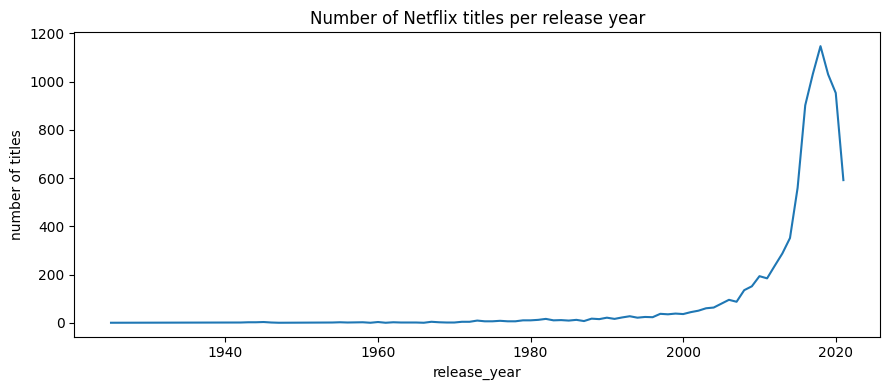

In [102]:
import matplotlib.pyplot as plt

# Trend: almost nothing before the 1990s, then a steep climb that peaks
# around 2018-2020 and dips slightly for the newest years, because the
# catalogue was scraped in 2021 and very new titles were still being added.
per_year = df.groupby("release_year").size()
per_year.plot(kind="line", figsize=(9, 4), title="Number of Netflix titles per release year")
plt.xlabel("release_year")
plt.ylabel("number of titles")
plt.tight_layout()
plt.show()

#### Q103. Group by `year_added`-style logic isn't possible yet — `date_added` is still text! Group by the **first 4 characters trick is wrong**. Explain in a comment why we need Section G (Cleaning) before we can group by the year a title was ADDED.

In [103]:
# WHY WE NEED SECTION G FIRST
#
# date_added is still plain TEXT, e.g. "September 25, 2021".
# 1) Taking the first 4 characters gives "Sept", not a year - the year sits at
#    the END of the string, and the month name has a different length every month.
# 2) Even str[-4:] would be fragile: some rows have extra spaces, and 10 rows
#    are missing entirely, so the slice would break or give rubbish.
# 3) Text sorts alphabetically, so "April 2019" would come before "January 2016".
#
# The correct fix is pd.to_datetime() in Section G. Once date_added is a real
# datetime column we can just use .dt.year - that is what Q114 does.
print(df["date_added"].dtype)
df["date_added"].head()

object


0    September 25, 2021
1    September 24, 2021
2    September 24, 2021
3    September 24, 2021
4    September 24, 2021
Name: date_added, dtype: object

#### Q104. Group by `type` and compute the **median** `release_year`.

In [104]:
# median = the middle value, less affected by a few very old titles than mean
df.groupby("type")["release_year"].median()

type
Movie      2016.0
TV Show    2018.0
Name: release_year, dtype: float64

#### Q105. Challenge: for each `rating`, what percentage of titles are Movies? (hint: group by rating, compute the mean of `is_movie`, multiply by 100)

In [105]:
# is_movie is True/False. The MEAN of a boolean column is the proportion of
# True values, so multiplying by 100 turns it into a percentage.
pct = (df.groupby("rating")["is_movie"].mean() * 100).round(1)
pct.sort_values(ascending=False)

rating
66 min      100.0
74 min      100.0
84 min      100.0
G           100.0
NC-17       100.0
PG          100.0
PG-13       100.0
UR          100.0
R            99.7
NR           93.8
TV-Y7-FV     83.3
TV-14        66.1
TV-MA        64.3
TV-PG        62.6
TV-G         57.3
UNRATED      50.0
TV-Y         42.7
TV-Y7        41.6
Name: is_movie, dtype: float64

## Section G — Cleaning (Q106–Q125)

#### Q106. Re-check missing values per column (things changed since Section A!).

In [106]:
# rating is already clean (Q75 filled it), but director/cast/country are not
df.isna().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             0
duration           3
genres             0
description        0
age_years          0
is_movie           0
is_recent          0
title_length       0
platform           0
era                0
dtype: int64

#### Q107. Fill missing `director` values with `"Unknown"`.

In [107]:
df["director"] = df["director"].fillna("Unknown")
print("director missing:", df["director"].isna().sum())

director missing: 0


#### Q108. Fill missing `cast` values with `"Unknown"`.

In [108]:
df["cast"] = df["cast"].fillna("Unknown")
print("cast missing:", df["cast"].isna().sum())

cast missing: 0


#### Q109. Fill missing `country` values with the **most common** country (hint: `mode()[0]`).

In [109]:
# mode() returns a Series (there can be ties), so we take [0]
most_common = df["country"].mode()[0]
print("Most common country:", most_common)
df["country"] = df["country"].fillna(most_common)
print("country missing:", df["country"].isna().sum())

Most common country: USA
country missing: 0


#### Q110. Count the rows where `date_added` is missing, then drop those rows.

In [110]:
print("Rows with missing date_added:", df["date_added"].isna().sum())
print("Rows before:", len(df))

df = df.dropna(subset=["date_added"])

print("Rows after :", len(df))

Rows with missing date_added: 10
Rows before: 8807
Rows after : 8797


#### Q111. `date_added` has extra spaces in some rows — strip them (hint: `str.strip`).

In [111]:
# Some values look like " September 9, 2019" with a leading space
before = (df["date_added"] != df["date_added"].str.strip()).sum()
df["date_added"] = df["date_added"].str.strip()
print("Rows that had extra spaces:", before)
df["date_added"].head()

Rows that had extra spaces: 88


0    September 25, 2021
1    September 24, 2021
2    September 24, 2021
3    September 24, 2021
4    September 24, 2021
Name: date_added, dtype: object

#### Q112. Convert `date_added` to datetime with `pd.to_datetime`. Check the dtype after.

In [112]:
# format tells pandas exactly how the text is written: "September 25, 2021"
#   %B = full month name, %d = day, %Y = 4-digit year
# errors="coerce" turns anything unparseable into NaT instead of crashing.
df["date_added"] = pd.to_datetime(df["date_added"], format="%B %d, %Y", errors="coerce")
print("dtype now:", df["date_added"].dtype)
print("Failed to parse:", df["date_added"].isna().sum())
df["date_added"].head()

dtype now: datetime64[ns]
Failed to parse: 0


0   2021-09-25
1   2021-09-24
2   2021-09-24
3   2021-09-24
4   2021-09-24
Name: date_added, dtype: datetime64[ns]

#### Q113. NOW create `year_added` = `.dt.year` and `month_added` = `.dt.month_name()`.

In [113]:
# The .dt accessor is to datetimes what .str is to text
df["year_added"] = df["date_added"].dt.year
df["month_added"] = df["date_added"].dt.month_name()
df[["title", "date_added", "year_added", "month_added"]].head()

,title,date_added,year_added,month_added
0,My Favourite Show,2021-09-25,2021,September
1,Blood & Water,2021-09-24,2021,September
2,Ganglands,2021-09-24,2021,September
3,Jailbirds New Orleans,2021-09-24,2021,September
4,Kota Factory,2021-09-24,2021,September


#### Q114. Group by `year_added` and count — which year did Netflix add the most content? (This is the question F103 could not answer!)

In [114]:
per_year_added = df.groupby("year_added").size()
print("Netflix added the most content in:", per_year_added.idxmax(), "->", per_year_added.max(), "titles")
per_year_added

Netflix added the most content in: 2019 -> 2016 titles


year_added
2008       2
2009       2
2010       1
2011      13
2012       3
2013      11
2014      24
2015      82
2016     429
2017    1188
2018    1649
2019    2016
2020    1879
2021    1498
dtype: int64

#### Q115. Group by `month_added` and count — which month is most popular for adding content?

In [115]:
per_month = df.groupby("month_added").size().sort_values(ascending=False)
print("Most popular month for adding content:", per_month.idxmax())
per_month

Most popular month for adding content: July


month_added
July         827
December     813
September    770
April        764
October      760
August       755
March        742
January      738
June         728
November     705
May          632
February     563
dtype: int64

#### Q116. Look at the `duration` column with `unique()` (first 20 values) — what TWO different formats do you see?

In [116]:
# Two different formats live in the same column:
#   Movies   -> minutes, e.g. "90 min"
#   TV Shows -> seasons, e.g. "2 Seasons"
# That is why duration cannot simply be converted to a number.
df["duration"].unique()[:20]

array(['90 min', '2 Seasons', '1 Season', '91 min', '125 min',
       '9 Seasons', '104 min', '127 min', '4 Seasons', '67 min', '94 min',
       '5 Seasons', '161 min', '61 min', '166 min', '147 min', '103 min',
       '97 min', '106 min', '111 min'], dtype=object)

#### Q117. Extract the number from `duration` into a new column `duration_int` (hint: `str.extract(r"(\\d+)")` then `astype(float)`).

In [117]:
# str.extract pulls the first group ( ... ) out of each value.
# r"(\d+)" means "one or more digits". astype(float) tolerates the missing ones.
df["duration_int"] = df["duration"].str.extract(r"(\d+)").astype(float)
df[["title", "type", "duration", "duration_int"]].head()

,title,type,duration,duration_int
0,My Favourite Show,Movie,90 min,90.0
1,Blood & Water,TV Show,2 Seasons,2.0
2,Ganglands,TV Show,1 Season,1.0
3,Jailbirds New Orleans,TV Show,1 Season,1.0
4,Kota Factory,TV Show,2 Seasons,2.0


#### Q118. For Movies only: what is the average, minimum, and maximum duration in minutes?

In [118]:
# For movies duration_int is in MINUTES
movies = df.loc[df["type"] == "Movie", "duration_int"]
print("Average duration:", round(movies.mean(), 1), "min")
print("Shortest movie  :", movies.min(), "min")
print("Longest movie   :", movies.max(), "min")
movies.agg(["mean", "min", "max"])

Average duration: 99.6 min
Shortest movie  : 3.0 min
Longest movie   : 312.0 min


mean     99.577187
min       3.000000
max     312.000000
Name: duration_int, dtype: float64

#### Q119. For TV Shows only: how many have more than 5 seasons? Show their titles.

In [119]:
# For TV shows duration_int is the number of SEASONS
long_shows = df.loc[(df["type"] == "TV Show") & (df["duration_int"] > 5)]
print("TV Shows with more than 5 seasons:", len(long_shows))
long_shows[["title", "duration"]].sort_values("title")

TV Shows with more than 5 seasons: 96


,title,duration
323,30 Rock,7 Seasons
1701,American Horror Story,9 Seasons
2947,Arrow,8 Seasons
3369,BoJack Horseman,6 Seasons
4220,COMEDIANS of the world,13 Seasons
...,...,...
5054,Under Arrest,8 Seasons
4311,Voltron: Legendary Defender,8 Seasons
8710,Weeds,8 Seasons
1933,Wentworth,8 Seasons


#### Q120. Check duplicated **titles** (not full rows): are there any titles that appear more than once? Display them.

In [120]:
# subset="title" checks only that column; keep=False marks EVERY copy, not just the repeats
dups = df.loc[df.duplicated(subset="title", keep=False)].sort_values("title")
print("Rows involved in a duplicated title:", len(dups))
dups[["show_id", "title", "type", "country", "release_year"]]

Rows involved in a duplicated title: 0


,show_id,title,type,country,release_year


#### Q121. Are those duplicated titles real duplicates or different shows? Inspect a few with `.loc` and explain in a comment.

In [121]:
# In this copy of the dataset every title is unique, so there is nothing to
# inspect - the check in Q120 came back empty.
#
# In general a repeated title is NOT automatically a duplicate row. The same
# name can belong to two genuinely different entries, for example:
#   - a Movie and a TV Show that share a name
#   - a film and its remake, made in different years or different countries
# So the correct test is a full-row check (df.duplicated()), or comparing
# type / release_year / country before deciding to delete anything.
dup_titles = df.loc[df.duplicated(subset="title", keep=False), "title"].unique()

if len(dup_titles) == 0:
    print("No duplicated titles in this dataset - nothing to inspect.")
else:
    for t in dup_titles[:3]:
        print(df.loc[df["title"] == t, ["show_id", "title", "type", "release_year", "country"]])
        print("-" * 60)

No duplicated titles in this dataset - nothing to inspect.


#### Q122. The `rating` column contains some WRONG values that are actually durations (like `"74 min"`) — find them (hint: `str.contains("min", na=False)`).

In [122]:
# A handful of rows were shifted when the file was built, so a duration
# ended up in the rating column.
wrong = df.loc[df["rating"].str.contains("min", na=False)]
print("Wrong rating values:", wrong["rating"].unique())
wrong[["show_id", "title", "rating", "duration"]]

Wrong rating values: ['74 min' '84 min' '66 min']


,show_id,title,rating,duration
5541,s5542,Louis C.K. 2017,74 min,NaN
5794,s5795,Louis C.K.: Hilarious,84 min,NaN
5813,s5814,Louis C.K.: Live at the Comedy Store,66 min,NaN


#### Q123. Fix those wrong rating rows: set their `rating` to `"UNRATED"` using `.loc`.

In [123]:
df.loc[df["rating"].str.contains("min", na=False), "rating"] = "UNRATED"
print("Any 'min' left in rating?", df["rating"].str.contains("min", na=False).sum())
df["rating"].value_counts()

Any 'min' left in rating? 0


rating
TV-MA       3205
TV-14       2157
TV-PG        861
R            799
PG-13        490
TV-Y7        333
TV-Y         306
PG           287
TV-G         220
NR            79
G             41
UNRATED        7
TV-Y7-FV       6
NC-17          3
UR             3
Name: count, dtype: int64

#### Q124. Final check: run `info()` and `isna().sum()` — is the dataset clean now? Summarize what you fixed in a comment.

In [124]:
# WHAT WE FIXED IN SECTION G
#   Q107  director : missing -> "Unknown"
#   Q108  cast     : missing -> "Unknown"
#   Q109  country  : missing -> most common country
#   Q110  date_added : 10 rows with no date were dropped
#   Q111  date_added : stripped the extra spaces
#   Q112  date_added : text -> real datetime column
#   Q113  added year_added and month_added
#   Q117  added duration_int (the number pulled out of "90 min" / "2 Seasons")
#   Q123  rating   : the "74 min" style values were set to "UNRATED"
#   (Q75 earlier had already filled the missing ratings with "UNRATED")
#
# Remaining NaN sits only in duration_int, for the 3 rows whose duration was
# blank because the value had slipped into the rating column.
df.info()
print()
print(df.isna().sum())

<class 'pandas.core.frame.DataFrame'>
Index: 8797 entries, 0 to 8806
Data columns (total 21 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   show_id       8797 non-null   object        
 1   type          8797 non-null   object        
 2   title         8797 non-null   object        
 3   director      8797 non-null   object        
 4   cast          8797 non-null   object        
 5   country       8797 non-null   object        
 6   date_added    8797 non-null   datetime64[ns]
 7   release_year  8797 non-null   int32         
 8   rating        8797 non-null   object        
 9   duration      8794 non-null   object        
 10  genres        8797 non-null   object        
 11  description   8797 non-null   object        
 12  age_years     8797 non-null   int64         
 13  is_movie      8797 non-null   bool          
 14  is_recent     8797 non-null   bool          
 15  title_length  8797 non-null   int64        

#### Q125. Save your cleaned DataFrame to a new file `netflix_clean.csv` (without the index). This file is your submission proof!

In [125]:
# index=False keeps the saved file clean - no extra unnamed 0,1,2,... column
df.to_csv("../data/netflix_clean.csv", index=False)
print("Saved ../data/netflix_clean.csv")
print("Shape:", df.shape)
pd.read_csv("../data/netflix_clean.csv").head()

Saved ../data/netflix_clean.csv
Shape: (8797, 21)


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,...,description,age_years,is_movie,is_recent,title_length,platform,era,year_added,month_added,duration_int
0,s1,Movie,My Favourite Show,Kirsten Johnson,Unknown,USA,2021-09-25,2020,PG-13,90 min,...,"As her father nears the end of his life, filmm...",7,True,True,20,Netflix,new,2021,September,90.0
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,...,"After crossing paths at a party, a Cape Town t...",6,False,True,13,Netflix,new,2021,September,2.0
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",USA,2021-09-24,2021,TV-MA,1 Season,...,To protect his family from a powerful drug lor...,6,False,True,9,Netflix,new,2021,September,1.0
3,s4,TV Show,Jailbirds New Orleans,Unknown,Unknown,USA,2021-09-24,2021,TV-MA,1 Season,...,"Feuds, flirtations and toilet talk go down amo...",6,False,True,21,Netflix,new,2021,September,1.0
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,...,In a city of coaching centers known to train I...,6,False,True,12,Netflix,new,2021,September,2.0


---
## Submission
- Answer **all 125 questions** — partial answers get partial marks
- Run All must work top to bottom without errors (−5 marks if it crashes)
- Submit BOTH files: `YourName_workbook.ipynb` and `netflix_clean.csv`